# SECTION 00 — Project Introduction

 ## Brain Tumor/Cancer Classification from MRI Images Using Deep Learning

## Project Objective

The goal of this project is to develop a deep learning system that
classifies brain MRI images into three tumor categories:

1. Glioma
2. Meningioma
3. Pituitary tumor

The project demonstrates a complete Computer Vision and Deep Learning
pipeline, from raw MRI images to model training, evaluation, and
explainability.

---

## What will we learn?

This project introduces the fundamental concepts of:

- Computer Vision
- Digital image representation
- Image preprocessing
- Data augmentation
- Convolutional Neural Networks (CNNs)
- Transfer learning
- Model training
- Model evaluation
- Confusion matrices
- Classification metrics
- Model explainability

---

## Important Note

This project is an educational machine-learning system for image
classification. It is not a medical diagnostic system and should not
be used to make clinical decisions.

# SECTION 01 — Environment Setup

# 1. Environment Setup

Before working with the MRI images, we import the libraries required
for data handling, visualization, image processing, and deep learning.

### Main tools

- NumPy → numerical operations
- Pandas → tabular data
- Matplotlib → visualization
- PIL → image handling
- h5py → reading MATLAB v7.3 files
- TensorFlow/Keras → deep learning
- scikit-learn → evaluation metrics

In [123]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import h5py

import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# Display versions
# ------------------------------------------------------------

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)

print(f"Python-compatible NumPy : {np.__version__}")
print(f"TensorFlow              : {tf.__version__}")

print("\nGPU devices:")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print(" ", gpu)
else:
    print("  No GPU detected")

ENVIRONMENT
Python-compatible NumPy : 2.0.2
TensorFlow              : 2.20.0

GPU devices:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


# SECTION 02 — Dataset Configuration

## 2. Dataset Configuration

The dataset is stored as MATLAB v7.3 files.

Each `.mat` file contains a structure called `cjdata`.

Important fields include:

- `image` → MRI image
- `label` → numerical class label
- `PID` → patient identifier
- `tumorMask` → tumor segmentation mask
- `tumorBorder` → tumor boundary information

The patient identifier is especially important because multiple MRI
images can belong to the same patient.

Therefore, our data splitting strategy will operate at the patient level.

In [124]:
# ============================================================
# 2. DATASET CONFIGURATION
# ============================================================
# INTENTION:
# Locate the Brain Tumor Dataset and identify the individual
# MATLAB image files that we will use for computer vision.
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/kaggle/input/datasets/nahin333/brain-tumor-dataset")

print("=" * 60)
print("DATASET CONFIGURATION")
print("=" * 60)

print(f"\nDataset path:\n{DATASET_DIR}")
print(f"\nExists: {DATASET_DIR.exists()}")

# ------------------------------------------------------------
# Find only numbered image MAT files
# ------------------------------------------------------------

mat_files = sorted(
    [
        path
        for path in DATASET_DIR.glob("**/*.mat")
        if path.stem.isdigit()
    ],
    key=lambda x: int(x.stem)
)

# cvind.mat is kept separately because it contains
# cross-validation information rather than an image.
CVIND_PATH = DATASET_DIR / "cvind.mat"

print(f"\nNumbered image MAT files : {len(mat_files)}")
print(f"CVIND file exists        : {CVIND_PATH.exists()}")

print("\nFirst 5 image files:")
for path in mat_files[:5]:
    print(path)

print("\nLast 5 image files:")
for path in mat_files[-5:]:
    print(path)

print("\n" + "=" * 60)
print("CONFIGURATION COMPLETE")
print("=" * 60)

DATASET CONFIGURATION

Dataset path:
/kaggle/input/datasets/nahin333/brain-tumor-dataset

Exists: True

Numbered image MAT files : 3064
CVIND file exists        : True

First 5 image files:
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/1.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/2.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/3.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/4.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/5.mat

Last 5 image files:
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_2299-3064/3060.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_2299-3064/3061.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_2299-3064/3062.mat
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_2299-3064/3063.

# SECTION 03 — Load the Master Metadata

## 3. Build the Dataset Metadata

Instead of loading all MRI images into memory immediately, we first
create a metadata table.

This is an important Computer Vision workflow:

> Metadata first → images later.

The metadata tells us:

- where the image is stored
- which patient it belongs to
- which class it represents
- which predefined patient-level fold it belongs to

This allows us to design a leakage-free experiment before loading
thousands of images.

In [125]:
# ============================================================
# 3. BUILD MASTER METADATA
# ============================================================



# ------------------------------------------------------------
# Diagnosis mapping from the dataset labels
# ------------------------------------------------------------

LABEL_MAP = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

# ------------------------------------------------------------
# Find only numbered MAT files
# Exclude cvind.mat
# ------------------------------------------------------------

mat_files = sorted(
    [
        p for p in DATASET_DIR.glob("**/*.mat")
        if p.stem.isdigit()
    ],
    key=lambda p: int(p.stem)
)

print("=" * 60)
print("BUILDING METADATA DATAFRAME")
print("=" * 60)

print(f"MAT files found: {len(mat_files):,}")

# ------------------------------------------------------------
# Extract metadata
# ------------------------------------------------------------

records = []

for i, mat_path in enumerate(mat_files, start=1):

    with h5py.File(mat_path, "r") as f:

        cjdata = f["cjdata"]

        image = np.array(cjdata["image"])
        label = int(np.array(cjdata["label"]).squeeze())

        pid_raw = np.array(cjdata["PID"]).flatten()

        # Convert PID ASCII codes to string
        pid = "".join(
            chr(int(x)) for x in pid_raw
        )

        tumor_mask = np.array(
            cjdata["tumorMask"]
        )

        tumor_border = np.array(
            cjdata["tumorBorder"]
        )

        records.append({
            "file": str(mat_path),
            "file_id": int(mat_path.stem),
            "image_height": image.shape[0],
            "image_width": image.shape[1],
            "label": label,
            "diagnosis": LABEL_MAP[label],
            "PID": pid,
            "mask_shape": tumor_mask.shape,
            "mask_nonzero_pixels": int(
                np.count_nonzero(tumor_mask)
            ),
            "border_length": tumor_border.shape[-1]
        })

    if i % 500 == 0 or i == len(mat_files):
        print(f"Processed: {i:,}/{len(mat_files):,}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

metadata_df = pd.DataFrame(records)

# Sort by file ID
metadata_df = metadata_df.sort_values(
    "file_id"
).reset_index(drop=True)

print("\n" + "=" * 60)
print("METADATA DATAFRAME READY")
print("=" * 60)

print(f"Shape: {metadata_df.shape}")

print("\nColumns:")
print(metadata_df.columns.tolist())

print("\nFirst 5 records:")
display(metadata_df.head())

BUILDING METADATA DATAFRAME
MAT files found: 3,064
Processed: 500/3,064
Processed: 1,000/3,064
Processed: 1,500/3,064
Processed: 2,000/3,064
Processed: 2,500/3,064
Processed: 3,000/3,064
Processed: 3,064/3,064

METADATA DATAFRAME READY
Shape: (3064, 10)

Columns:
['file', 'file_id', 'image_height', 'image_width', 'label', 'diagnosis', 'PID', 'mask_shape', 'mask_nonzero_pixels', 'border_length']

First 5 records:


,file,file_id,image_height,image_width,label,diagnosis,PID,mask_shape,mask_nonzero_pixels,border_length
0,/kaggle/input/datasets/nahin333/brain-tumor-da...,1,512,512,1,meningioma,100360,"(512, 512)",4569,38
1,/kaggle/input/datasets/nahin333/brain-tumor-da...,2,512,512,1,meningioma,100360,"(512, 512)",8630,64
2,/kaggle/input/datasets/nahin333/brain-tumor-da...,3,512,512,1,meningioma,100360,"(512, 512)",10511,58
3,/kaggle/input/datasets/nahin333/brain-tumor-da...,4,512,512,1,meningioma,100360,"(512, 512)",8897,62
4,/kaggle/input/datasets/nahin333/brain-tumor-da...,5,512,512,1,meningioma,100360,"(512, 512)",11250,32


# SECTION 04 — Understand the Image

## 4. Understanding an MRI Image

### What is Computer Vision?

Computer Vision is the field of Artificial Intelligence that enables
computers to extract useful information from images and other visual
data.

A computer does not see an MRI the way a human does.

Instead, an image is represented as numerical values called pixels.

For a grayscale image:

    Image = Height × Width

For example:

    512 × 512

means the image contains:

    512 × 512 = 262,144 pixels

Each pixel represents image intensity.

A deep learning model learns patterns from these numerical values.

Image shape: (512, 512)
Data type: int16
Minimum pixel value: 0
Maximum pixel value: 3366


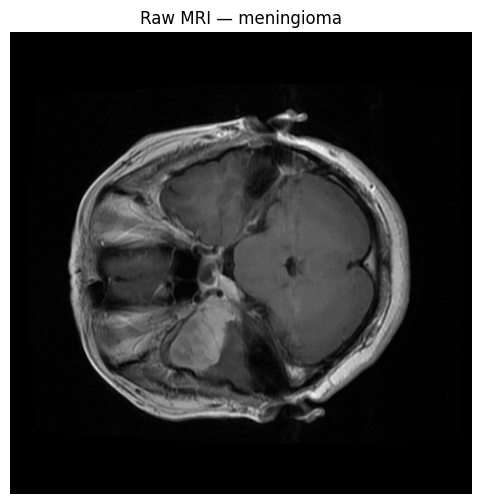

In [126]:
# ============================================================
# 4. VISUALIZE A RAW MRI
# ============================================================

sample_file = df.iloc[0]["file"]

with h5py.File(sample_file, "r") as f:
    sample_image = f["cjdata/image"][:]

print("Image shape:", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Minimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())

plt.figure(figsize=(6, 6))

plt.imshow(
    sample_image,
    cmap="gray"
)

plt.title(
    f"Raw MRI — {df.iloc[0]['diagnosis']}"
)

plt.axis("off")
plt.show()

###  Key idea

The image above is not stored as "a picture" inside the neural network.

It becomes a numerical tensor.

For example:

    512 × 512

can become:

    224 × 224 × 3

after preprocessing.

The neural network operates on this tensor.

# SECTION 05 — Show the Tumor Mask

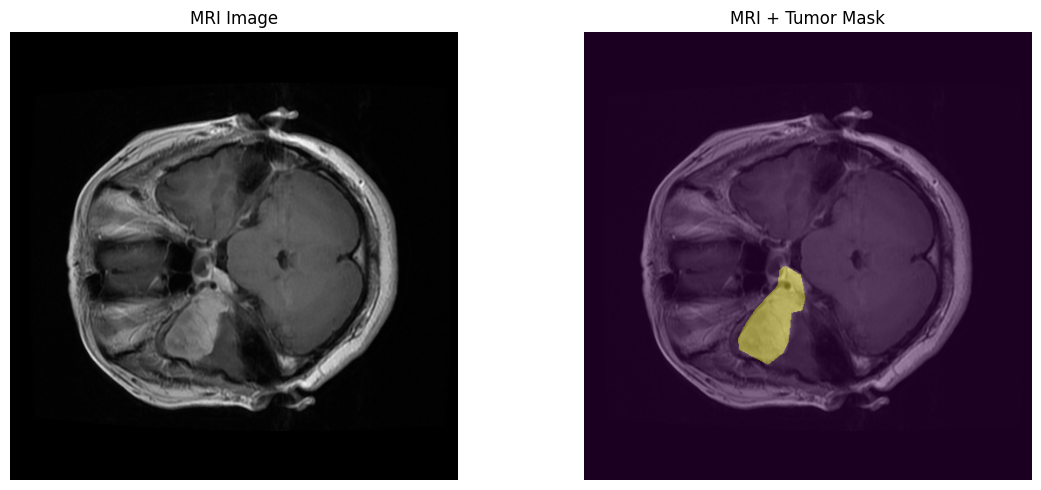

In [127]:
# ============================================================
# 5. MRI + TUMOR MASK
# ============================================================

sample_file = df.iloc[0]["file"]

with h5py.File(sample_file, "r") as f:
    image = f["cjdata/image"][:]
    mask = f["cjdata/tumorMask"][:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("MRI Image")
axes[0].axis("off")

axes[1].imshow(image, cmap="gray")
axes[1].imshow(
    mask,
    alpha=0.4
)
axes[1].set_title("MRI + Tumor Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Why is the tumor mask useful?

The mask identifies pixels associated with the tumor region.

Our primary task is classification, not segmentation.

Therefore, we will not use the mask as the target for the classifier.

However, the mask provides valuable information for understanding the
dataset and can later support our explainability analysis.

# SECTION 06 — Understand the Classes

diagnosis
glioma        1426
meningioma     708
pituitary      930
Name: count, dtype: int64


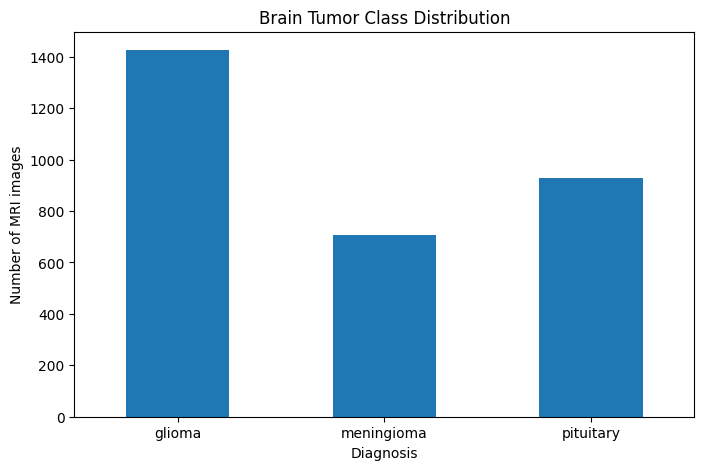

In [128]:
# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================

class_counts = (
    df["diagnosis"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print(class_counts)

plt.figure(figsize=(8, 5))

class_counts.plot(
    kind="bar"
)

plt.title("Brain Tumor Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of MRI images")
plt.xticks(rotation=0)

plt.show()

### What is classification?

Classification means assigning an input image to one of several
predefined categories.

Our model receives:

    MRI image

and produces probabilities such as:

    Glioma       0.82
    Meningioma   0.11
    Pituitary    0.07

The predicted class is the category with the highest probability.

This is a multi-class classification problem because there are three
possible classes.

# SECTION 07 — Patient-Level Split

## 7. Patient-Level Data Splitting

### Why not randomly split images?

A patient can have multiple MRI images.

For example:

    Patient A
       ├── MRI 1
       ├── MRI 2
       ├── MRI 3
       └── MRI 4

If MRI 1 and MRI 2 enter training while MRI 3 enters testing, the model
has effectively seen information from the same patient during training.

This is called **data leakage**.

Therefore:

> All images belonging to one patient must remain in the same split.

The dataset provides `cvind.mat`, and our audit confirmed that every
patient belongs to exactly one of its five folds.

Therefore we can use these predefined patient-safe folds.

In [129]:
# INTENTION:
# Create leakage-free training, validation, and test sets.
#
# IMPORTANT:
# We split by PATIENT, not by IMAGE.
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("SECTION 07 — PATIENT-LEVEL SPLIT")
print("=" * 60)

SECTION 07 — PATIENT-LEVEL SPLIT


In [130]:
# ============================================================
# 7.1 VERIFY PATIENT STRUCTURE
# ============================================================

print("Total image records :", len(df))
print("Unique patients     :", df["PID"].nunique())

print("\nImages per patient:")
print(df.groupby("PID").size().describe())

print("\nPatient diagnosis consistency:")

patient_diagnosis_counts = (
    df.groupby("PID")["diagnosis"]
      .nunique()
)

print(
    f"Patients with multiple diagnoses: "
    f"{(patient_diagnosis_counts > 1).sum()}"
)

Total image records : 3064
Unique patients     : 233

Images per patient:
count    233.000000
mean      13.150215
std        7.655779
min        1.000000
25%        7.000000
50%       13.000000
75%       18.000000
max       38.000000
dtype: float64

Patient diagnosis consistency:
Patients with multiple diagnoses: 0


In [131]:
# ============================================================
# 7.2 LOAD PREDEFINED CV FOLD ASSIGNMENTS
# ============================================================

import h5py

CVIND_PATH = DATASET_DIR / "cvind.mat"

with h5py.File(CVIND_PATH, "r") as f:
    cvind = np.array(f["cvind"]).flatten()

print("=" * 60)
print("CV FOLD INFORMATION")
print("=" * 60)

print("\nCVIND shape:", cvind.shape)
print("Unique folds:", np.unique(cvind))

CV FOLD INFORMATION

CVIND shape: (3064,)
Unique folds: [1. 2. 3. 4. 5.]


In [132]:
# ============================================================
# 7.3 ATTACH CV FOLD TO METADATA
# ============================================================

# Create mapping:
# file_id → CV fold

cvind_map = {
    file_id: int(fold)
    for file_id, fold in zip(range(1, len(cvind) + 1), cvind)
}

df["cv_fold"] = df["file_id"].map(cvind_map)

print("=" * 60)
print("CV FOLD ASSIGNMENT")
print("=" * 60)

print("\nMissing fold assignments:", df["cv_fold"].isna().sum())

print("\nImages per fold:")
print(df["cv_fold"].value_counts().sort_index())

CV FOLD ASSIGNMENT

Missing fold assignments: 0

Images per fold:
cv_fold
1    542
2    679
3    572
4    628
5    643
Name: count, dtype: int64


In [133]:
# ============================================================
# 7.4 PATIENT ↔ FOLD LEAKAGE CHECK
# ============================================================

patient_fold_counts = (
    df.groupby("PID")["cv_fold"]
      .nunique()
)

patients_in_multiple_folds = (
    patient_fold_counts > 1
).sum()

print("=" * 60)
print("PATIENT-LEVEL LEAKAGE CHECK")
print("=" * 60)

print(
    f"\nTotal patients: "
    f"{df['PID'].nunique()}"
)

print(
    f"Patients appearing in multiple folds: "
    f"{patients_in_multiple_folds}"
)

print(
    f"Patients appearing in exactly one fold: "
    f"{(patient_fold_counts == 1).sum()}"
)

PATIENT-LEVEL LEAKAGE CHECK

Total patients: 233
Patients appearing in multiple folds: 0
Patients appearing in exactly one fold: 233


### Before training the model, I checked whether the same patient could appear in multiple folds. None did. Therefore, our predefined cross-validation structure is patient-safe.

### Create the three splits

TRAIN = folds 1, 2, 3

VALIDATION = fold 4

TEST = fold 5

In [134]:
# ============================================================
# 7.5 CREATE TRAIN / VALIDATION / TEST SPLITS
# ============================================================

TRAIN_FOLDS = [1, 2, 3]
VAL_FOLDS   = [4]
TEST_FOLDS  = [5]

train_df = df[df["cv_fold"].isin(TRAIN_FOLDS)].copy()
val_df   = df[df["cv_fold"].isin(VAL_FOLDS)].copy()
test_df  = df[df["cv_fold"].isin(TEST_FOLDS)].copy()

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(f"\nTraining images   : {len(train_df)}")
print(f"Validation images : {len(val_df)}")
print(f"Test images       : {len(test_df)}")

print(f"\nTotal images      : {len(train_df) + len(val_df) + len(test_df)}")

DATASET SPLIT

Training images   : 1793
Validation images : 628
Test images       : 643

Total images      : 3064


### Check patient counts

Images alone aren't enough.

We also want to know how many patients are in each split.

In [135]:
# ============================================================
# 7.6 PATIENT COUNTS
# ============================================================

print("=" * 60)
print("PATIENT COUNTS")
print("=" * 60)

print(
    f"\nTraining patients   : {train_df['PID'].nunique()}"
)

print(
    f"Validation patients : {val_df['PID'].nunique()}"
)

print(
    f"Test patients       : {test_df['PID'].nunique()}"
)

print(
    f"\nTotal unique patients: "
    f"{df['PID'].nunique()}"
)

PATIENT COUNTS

Training patients   : 139
Validation patients : 47
Test patients       : 47

Total unique patients: 233


In [136]:
# ============================================================
# 7.7 FINAL PATIENT OVERLAP CHECK
# ============================================================

train_patients = set(train_df["PID"])
val_patients   = set(val_df["PID"])
test_patients  = set(test_df["PID"])

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("=" * 60)
print("FINAL PATIENT OVERLAP CHECK")
print("=" * 60)

print("\nTrain ↔ Validation overlap :", len(train_val_overlap))
print("Train ↔ Test overlap       :", len(train_test_overlap))
print("Validation ↔ Test overlap  :", len(val_test_overlap))

FINAL PATIENT OVERLAP CHECK

Train ↔ Validation overlap : 0
Train ↔ Test overlap       : 0
Validation ↔ Test overlap  : 0


In [137]:
# ============================================================
# 7.8 CLASS DISTRIBUTION ACROSS SPLITS
# ============================================================

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

distribution = pd.DataFrame({
    "Train": train_df["diagnosis"].value_counts(),
    "Validation": val_df["diagnosis"].value_counts(),
    "Test": test_df["diagnosis"].value_counts()
}).fillna(0).astype(int)

print("\nImage counts:")
print(distribution)

print("\nPercentages:")
print(
    distribution.div(distribution.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

CLASS DISTRIBUTION

Image counts:
            Train  Validation  Test
diagnosis                          
glioma        814         325   287
pituitary     561         179   190
meningioma    418         124   166

Percentages:
            Train  Validation   Test
diagnosis                           
glioma      45.40       51.75  44.63
pituitary   31.29       28.50  29.55
meningioma  23.31       19.75  25.82


In [138]:
# ============================================================
# 7.9 SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "CV Folds": ["1, 2, 3", "4", "5"],
    "Images": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Patients": [
        train_df["PID"].nunique(),
        val_df["PID"].nunique(),
        test_df["PID"].nunique()
    ]
})

print("=" * 60)
print("FINAL DATASET SPLIT SUMMARY")
print("=" * 60)

display(split_summary)

FINAL DATASET SPLIT SUMMARY


,Split,CV Folds,Images,Patients
0,Training,"1, 2, 3",1793,139
1,Validation,4,628,47
2,Test,5,643,47


In [139]:
# ============================================================
# 7.10 DATA INTEGRITY ASSERTIONS
# ============================================================

assert len(train_df) > 0
assert len(val_df) > 0
assert len(test_df) > 0

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

assert train_df["PID"].nunique() + \
       val_df["PID"].nunique() + \
       test_df["PID"].nunique() == df["PID"].nunique()

assert len(train_df) + \
       len(val_df) + \
       len(test_df) == len(df)

print("=" * 60)
print("DATA INTEGRITY CHECK PASSED")
print("=" * 60)

print("""
✓ All images assigned to exactly one split
✓ No patient overlap between splits
✓ Training set isolated
✓ Validation set isolated
✓ Test set isolated
✓ Patient-level leakage prevented
""")

DATA INTEGRITY CHECK PASSED

✓ All images assigned to exactly one split
✓ No patient overlap between splits
✓ Training set isolated
✓ Validation set isolated
✓ Test set isolated
✓ Patient-level leakage prevented



# SECTION 08 — MRI Image Preparation

### 8.1 Import the required libraries

Intention

We need:

* h5py → read MATLAB v7.3 .mat files
* numpy → manipulate image matrices
* PIL → resize images
* matplotlib → visualize MRI images
* tensorflow → eventually feed images into the CNN

In [140]:
# ============================================================
# SECTION 08 — MRI IMAGE PREPARATION
# ============================================================

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

print("=" * 60)
print("SECTION 08 — MRI IMAGE PREPARATION")
print("=" * 60)

print("\nTensorFlow version:", tf.__version__)

SECTION 08 — MRI IMAGE PREPARATION

TensorFlow version: 2.20.0


## 8.2 Understand the MRI representation

In [141]:
# ============================================================
# 8.1 LOAD ONE MRI IMAGE
# ============================================================

sample_path = mat_files[0]

print("Sample file:")
print(sample_path)

with h5py.File(sample_path, "r") as f:
    image = np.array(f["cjdata/image"])

print("\nImage shape :", image.shape)
print("Data type   :", image.dtype)
print("Minimum     :", image.min())
print("Maximum     :", image.max())

Sample file:
/kaggle/input/datasets/nahin333/brain-tumor-dataset/brainTumorDataPublic_1-766/1.mat

Image shape : (512, 512)
Data type   : int16
Minimum     : 0
Maximum     : 3366


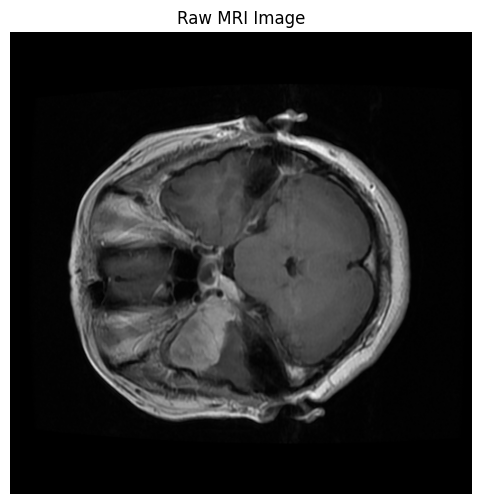

In [142]:
# ============================================================
# 8.2 VISUALIZE RAW MRI
# ============================================================

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")

plt.title("Raw MRI Image")
plt.axis("off")

plt.show()

In [143]:
# ============================================================
# 8.3 LOAD TUMOR MASK
# ============================================================

with h5py.File(sample_path, "r") as f:
    tumor_mask = np.array(f["cjdata/tumorMask"])

print("Tumor mask shape :", tumor_mask.shape)
print("Mask data type   :", tumor_mask.dtype)
print("Mask minimum     :", tumor_mask.min())
print("Mask maximum     :", tumor_mask.max())
print(
    "Non-zero pixels  :",
    np.count_nonzero(tumor_mask)
)

Tumor mask shape : (512, 512)
Mask data type   : uint8
Mask minimum     : 0
Mask maximum     : 1
Non-zero pixels  : 4569


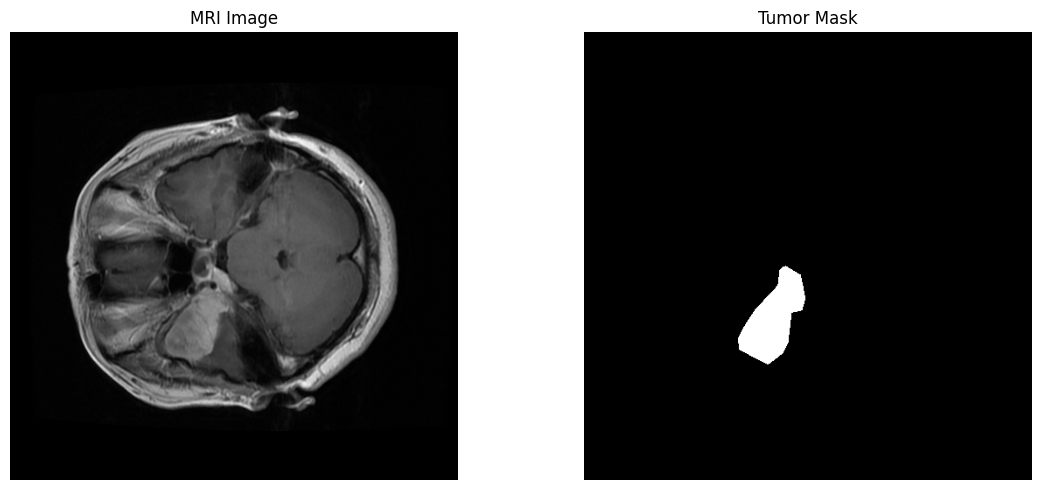

In [144]:
# ============================================================
# 8.4 MRI AND TUMOR MASK
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(image, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(tumor_mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [145]:
# ============================================================
# 8.5 READ LABEL
# ============================================================

with h5py.File(sample_path, "r") as f:
    label = int(np.array(f["cjdata/label"]).squeeze())

print("Numeric label:", label)

Numeric label: 1


In [146]:
# ============================================================
# 8.6 LABEL MAPPING
# ============================================================

LABEL_MAP = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print(LABEL_MAP)

print("\nSample diagnosis:")
print(LABEL_MAP[label])

{1: 'meningioma', 2: 'glioma', 3: 'pituitary'}

Sample diagnosis:
meningioma


In [147]:
# ============================================================
# 8.7 NORMALIZE IMAGE
# ============================================================

def normalize_image(image):
    """
    Convert MRI pixel values to float32
    and scale them to [0, 1].
    """

    image = image.astype(np.float32)

    image_min = image.min()
    image_max = image.max()

    if image_max == image_min:
        return np.zeros_like(image, dtype=np.float32)

    image = (image - image_min) / (image_max - image_min)

    return image

In [148]:
normalized_image = normalize_image(image)

print("Normalized dtype :", normalized_image.dtype)
print("Normalized min   :", normalized_image.min())
print("Normalized max   :", normalized_image.max())

Normalized dtype : float32
Normalized min   : 0.0
Normalized max   : 1.0


### Why resize the images?
Our audit showed that this dataset contains two image sizes:

512 × 512
256 × 256
- A neural network needs a consistent input shape.
- Therefore we choose a standard CNN input size.

For this project we'll use:

224 × 224
- This reduces computational cost while retaining useful spatial information.
- We'll use TensorFlow for resizing.

In [149]:
# ============================================================
# 8.8 RESIZE IMAGE
# ============================================================

IMG_SIZE = 224

def resize_image(image, size=IMG_SIZE):
    """
    Resize a normalized grayscale MRI image.
    """

    image_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.float32
    )

    image_tensor = tf.image.resize(
        image_tensor[..., np.newaxis],
        [size, size],
        method="bilinear"
    )

    return image_tensor.numpy()

In [150]:
resized_image = resize_image(normalized_image)

print("Original shape :", normalized_image.shape)
print("Resized shape  :", resized_image.shape)

Original shape : (512, 512)
Resized shape  : (224, 224, 1)


### Why (224, 224, 1)?
This is an important deep-learning concept.
* The shape:
224 × 224 × 1
* means:
224 → height
224 → width
1   → channel
* Because MRI is grayscale:
Channels = 1
* Compare that with an RGB photograph:
224 × 224 × 3
                  ↑
            Red Green Blue

## 8.9 COMPLETE MRI PREPROCESSING FUNCTION

In [151]:
# ============================================================
# 8.9 COMPLETE MRI PREPROCESSING FUNCTION
# ============================================================

def preprocess_mri(image, size=IMG_SIZE):
    """
    Complete preprocessing pipeline for one MRI image.

    Steps:
        1. Convert to float32
        2. Normalize pixels to [0, 1]
        3. Resize to fixed dimensions
        4. Add grayscale channel
    """

    # --------------------------------------------------------
    # Step 1 — Convert datatype
    # --------------------------------------------------------
    image = image.astype(np.float32)

    # --------------------------------------------------------
    # Step 2 — Normalize
    # --------------------------------------------------------
    image_min = image.min()
    image_max = image.max()

    if image_max > image_min:
        image = (image - image_min) / (
            image_max - image_min
        )
    else:
        image = np.zeros_like(
            image,
            dtype=np.float32
        )

    # --------------------------------------------------------
    # Step 3 + 4 — Resize + channel
    # --------------------------------------------------------
    image = tf.image.resize(
        image[..., np.newaxis],
        [size, size],
        method="bilinear"
    )

    return image.numpy().astype(np.float32)

In [152]:
processed = preprocess_mri(image)

print("=" * 60)
print("PREPROCESSING TEST")
print("=" * 60)

print("\nShape :", processed.shape)
print("Dtype :", processed.dtype)
print("Min   :", processed.min())
print("Max   :", processed.max())

PREPROCESSING TEST

Shape : (224, 224, 1)
Dtype : float32
Min   : 0.0
Max   : 0.9759195


## 8.10 Compare before and after preprocessing

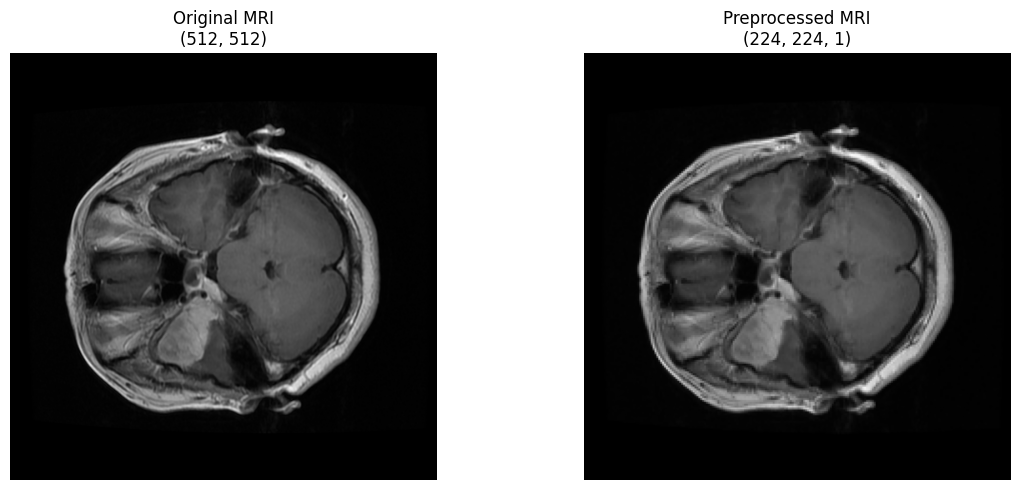

In [153]:
# ============================================================
# 8.10 BEFORE vs AFTER
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(image, cmap="gray")
plt.title(f"Original MRI\n{image.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(processed.squeeze(), cmap="gray")
plt.title(f"Preprocessed MRI\n{processed.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 8.11 Create a reusable MAT-file loader

In [154]:
# ============================================================
# 8.11 MAT FILE LOADER
# ============================================================

def load_mri_mat(mat_path):
    """
    Load image, label, mask, and patient ID
    from one MATLAB v7.3 file.
    """

    with h5py.File(mat_path, "r") as f:

        image = np.array(
            f["cjdata/image"]
        )

        label = int(
            np.array(
                f["cjdata/label"]
            ).squeeze()
        )

        tumor_mask = np.array(
            f["cjdata/tumorMask"]
        )

        pid = np.array(
            f["cjdata/PID"]
        ).flatten()

    return image, label, tumor_mask, pid

In [155]:
image, label, mask, pid = load_mri_mat(
    mat_files[0]
)

print("=" * 60)
print("MAT FILE LOADER TEST")
print("=" * 60)

print("\nImage shape :", image.shape)
print("Label       :", label)
print("Diagnosis   :", LABEL_MAP[label])
print("Mask shape  :", mask.shape)
print("PID         :", pid)

MAT FILE LOADER TEST

Image shape : (512, 512)
Label       : 1
Diagnosis   : meningioma
Mask shape  : (512, 512)
PID         : [49 48 48 51 54 48]


### 8.12 Connect the loader to preprocessing

In [156]:
# ============================================================
# 8.12 LOAD + PREPROCESS ONE MRI
# ============================================================

image, label, mask, pid = load_mri_mat(
    mat_files[0]
)

processed_image = preprocess_mri(image)

print("=" * 60)
print("COMPLETE IMAGE PIPELINE")
print("=" * 60)

print("\nFile      :", mat_files[0].name)
print("Patient   :", pid)
print("Diagnosis :", LABEL_MAP[label])
print("Original  :", image.shape)
print("Processed :", processed_image.shape)

COMPLETE IMAGE PIPELINE

File      : 1.mat
Patient   : [49 48 48 51 54 48]
Diagnosis : meningioma
Original  : (512, 512)
Processed : (224, 224, 1)


## 8.16 Process a small batch

In [157]:
# Before processing all 3,064 images, let's verify the pipeline on a small sample.

In [158]:
# ============================================================
# 8.13 SMALL BATCH TEST
# ============================================================

SAMPLE_SIZE = 10

sample_images = []
sample_labels = []
sample_pids = []

for path in mat_files[:SAMPLE_SIZE]:

    image, label, mask, pid = load_mri_mat(path)

    processed = preprocess_mri(image)

    sample_images.append(processed)
    sample_labels.append(label)
    sample_pids.append(pid)

sample_images = np.stack(sample_images)
sample_labels = np.array(sample_labels)

print("=" * 60)
print("SMALL BATCH TEST")
print("=" * 60)

print("\nImages shape :", sample_images.shape)
print("Labels shape :", sample_labels.shape)
print("Labels       :", sample_labels)

SMALL BATCH TEST

Images shape : (10, 224, 224, 1)
Labels shape : (10,)
Labels       : [1 1 1 1 1 1 1 1 1 1]


## 8.13 Visualize multiple MRI samples

In [159]:
# Let's make sure our preprocessing didn't damage the images.

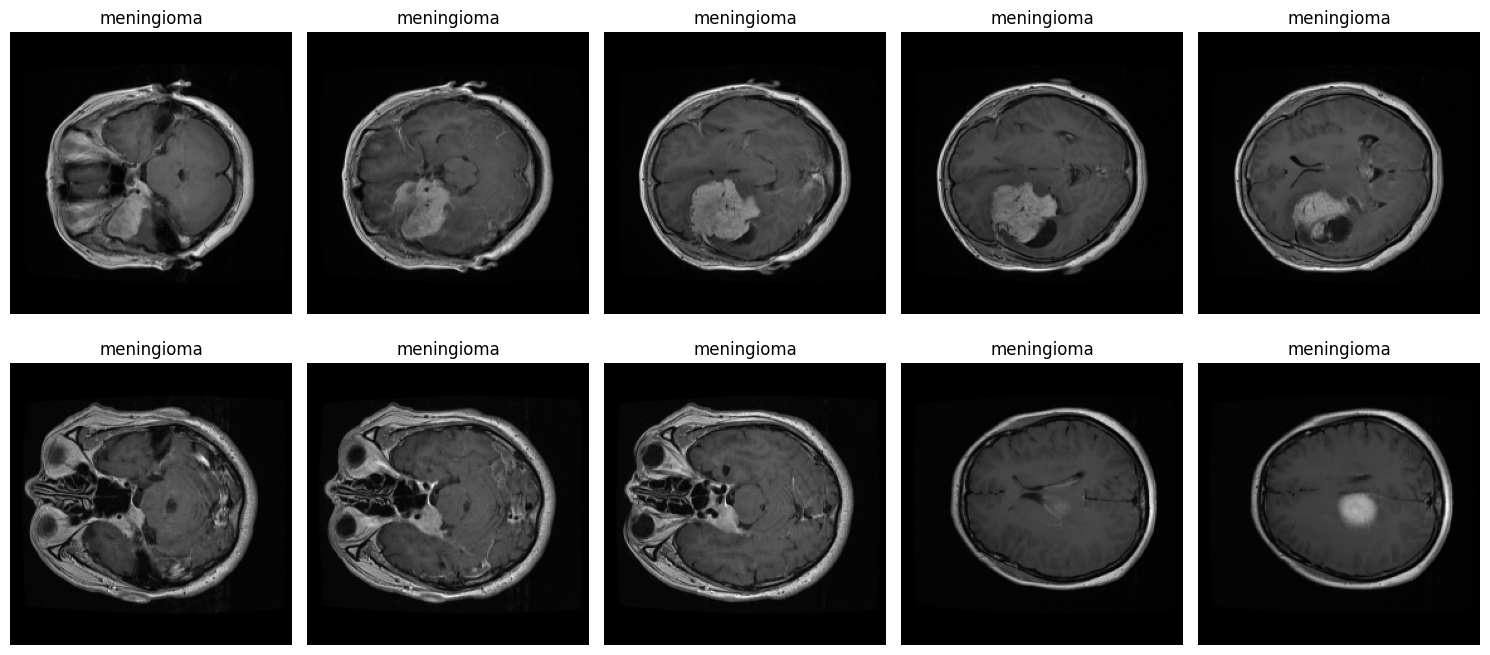

In [160]:
# ============================================================
# 8.14 VISUALIZE PREPROCESSED SAMPLES
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        sample_images[i].squeeze(),
        cmap="gray"
    )

    diagnosis = LABEL_MAP[
        sample_labels[i]
    ]

    ax.set_title(diagnosis)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8.15 Final shape verification

In [161]:
# ============================================================
# 8.15 FINAL PREPROCESSING VALIDATION
# ============================================================

assert sample_images.ndim == 4
assert sample_images.shape[1] == IMG_SIZE
assert sample_images.shape[2] == IMG_SIZE
assert sample_images.shape[3] == 1

assert sample_images.dtype == np.float32

assert sample_images.min() >= 0.0
assert sample_images.max() <= 1.0

print("=" * 60)
print("MRI PREPROCESSING VALIDATION PASSED")
print("=" * 60)

print("""
✓ Images converted to float32
✓ Pixel values normalized to [0, 1]
✓ Images resized to 224 × 224
✓ Grayscale channel added
✓ CNN-compatible tensor created
✓ Sample batch successfully processed
""")

MRI PREPROCESSING VALIDATION PASSED

✓ Images converted to float32
✓ Pixel values normalized to [0, 1]
✓ Images resized to 224 × 224
✓ Grayscale channel added
✓ CNN-compatible tensor created
✓ Sample batch successfully processed



# SECTION 09 — Exploratory Visualization & Class Analysis

The goal of this section is to answer:

1. What does each class look like?
2. Are the classes balanced?
3. How different are the image intensities?
4. What do the tumor masks look like?
5. How much variation exists between patients?
6. What will our CNN actually have to learn?

In [162]:
# ============================================================
# SECTION 09.1 — VISUALIZATION LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("SECTION 09 — EXPLORATORY VISUALIZATION & CLASS ANALYSIS")
print("=" * 60)

print("\nVisualization libraries loaded successfully.")

SECTION 09 — EXPLORATORY VISUALIZATION & CLASS ANALYSIS

Visualization libraries loaded successfully.


In [163]:
# ============================================================
# SECTION 09.2 — VERIFY METADATA
# ============================================================

required_columns = [
    "file",
    "file_id",
    "image_height",
    "image_width",
    "label",
    "diagnosis",
    "PID",
    "mask_shape",
    "mask_nonzero_pixels",
    "border_length"
]

missing_columns = [
    col for col in required_columns
    if col not in metadata_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("=" * 60)
print("METADATA VERIFICATION")
print("=" * 60)

print(f"\nRecords : {len(metadata_df):,}")
print(f"Columns : {len(metadata_df.columns)}")

print("\nRequired metadata columns:")
for col in required_columns:
    print(f"✓ {col}")

print("\nMetadata verification PASSED.")

METADATA VERIFICATION

Records : 3,064
Columns : 10

Required metadata columns:
✓ file
✓ file_id
✓ image_height
✓ image_width
✓ label
✓ diagnosis
✓ PID
✓ mask_shape
✓ mask_nonzero_pixels
✓ border_length

Metadata verification PASSED.


In [164]:
# ============================================================
# SECTION 09.3 — CLASS DEFINITIONS
# ============================================================

CLASS_NAMES = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

print("=" * 60)
print("CLASS DEFINITIONS")
print("=" * 60)

for label, name in CLASS_NAMES.items():
    print(f"Label {label} → {name}")

CLASS DEFINITIONS
Label 1 → meningioma
Label 2 → glioma
Label 3 → pituitary


In [165]:
# ============================================================
# SECTION 09.4 — CLASS DISTRIBUTION
# ============================================================

class_counts = (
    metadata_df["diagnosis"]
    .value_counts()
    .reindex(["glioma", "meningioma", "pituitary"])
)

class_percentages = (
    class_counts / class_counts.sum() * 100
)

class_distribution = pd.DataFrame({
    "image_count": class_counts,
    "percentage": class_percentages.round(2)
})

print("=" * 60)
print("IMAGE-LEVEL CLASS DISTRIBUTION")
print("=" * 60)

print(class_distribution)

IMAGE-LEVEL CLASS DISTRIBUTION
            image_count  percentage
diagnosis                          
glioma             1426       46.54
meningioma          708       23.11
pituitary           930       30.35


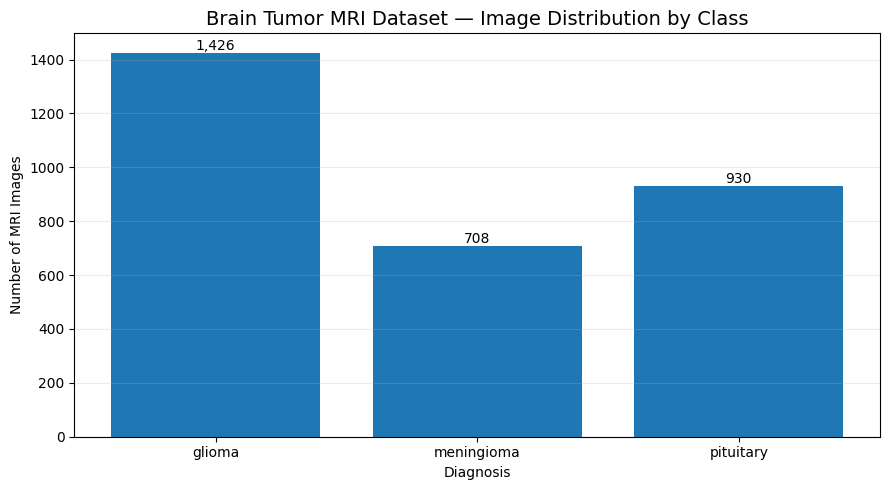

In [166]:
# ============================================================
# SECTION 09.5 — CLASS DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    class_distribution.index,
    class_distribution["image_count"]
)

plt.title(
    "Brain Tumor MRI Dataset — Image Distribution by Class",
    fontsize=14
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of MRI Images")

plt.grid(
    axis="y",
    alpha=0.25
)

for bar, count in zip(
    bars,
    class_distribution["image_count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### The dataset contains three tumor categories. Glioma is the largest class with 1,426 images, followed by pituitary with 930 and meningioma with 708. Therefore, the dataset is not perfectly balanced, so later we will evaluate the model using more than accuracy alone.

In [167]:
# ============================================================
# SECTION 09.6 — PATIENT-LEVEL CLASS DISTRIBUTION
# ============================================================

patient_df = (
    metadata_df[
        ["PID", "diagnosis"]
    ]
    .drop_duplicates()
)

patient_class_counts = (
    patient_df["diagnosis"]
    .value_counts()
    .reindex(["glioma", "meningioma", "pituitary"])
)

patient_class_percentages = (
    patient_class_counts /
    patient_class_counts.sum() * 100
)

patient_distribution = pd.DataFrame({
    "patient_count": patient_class_counts,
    "percentage": patient_class_percentages.round(2)
})

print("=" * 60)
print("PATIENT-LEVEL CLASS DISTRIBUTION")
print("=" * 60)

print(patient_distribution)

print(
    f"\nTotal unique patients: "
    f"{patient_df['PID'].nunique()}"
)

PATIENT-LEVEL CLASS DISTRIBUTION
            patient_count  percentage
diagnosis                            
glioma                 89       38.20
meningioma             82       35.19
pituitary              62       26.61

Total unique patients: 233


In [168]:
# ============================================================
# SECTION 09.7 — IMAGES PER PATIENT
# ============================================================

images_per_patient = (
    metadata_df
    .groupby("PID")
    .size()
)

print("=" * 60)
print("IMAGES PER PATIENT")
print("=" * 60)

print(images_per_patient.describe())

IMAGES PER PATIENT
count    233.000000
mean      13.150215
std        7.655779
min        1.000000
25%        7.000000
50%       13.000000
75%       18.000000
max       38.000000
dtype: float64


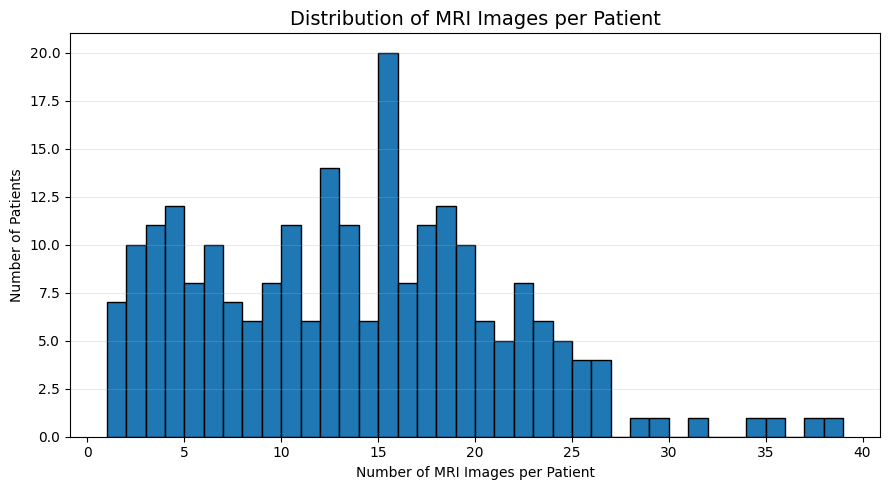

In [169]:
# ============================================================
# SECTION 09.8 — PATIENT IMAGE COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    images_per_patient,
    bins=range(
        int(images_per_patient.min()),
        int(images_per_patient.max()) + 2
    ),
    edgecolor="black"
)

plt.title(
    "Distribution of MRI Images per Patient",
    fontsize=14
)

plt.xlabel("Number of MRI Images per Patient")
plt.ylabel("Number of Patients")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

#### A single patient can contribute multiple MRI images. Because these images may contain highly similar anatomical information, randomly splitting images could allow information from the same patient to appear in both training and testing. We therefore split at the patient level.

In [170]:
# ============================================================
# SECTION 09.9 — REPRESENTATIVE MRI IMAGES
# ============================================================

from pathlib import Path
import h5py

def load_mri_from_mat(mat_path):
    """
    Load MRI image and tumor mask from a MATLAB v7.3 file.
    """

    with h5py.File(mat_path, "r") as f:
        image = np.array(
            f["cjdata"]["image"]
        )

        mask = np.array(
            f["cjdata"]["tumorMask"]
        )

    return image, mask


print("=" * 60)
print("REPRESENTATIVE MRI IMAGE VISUALIZATION")
print("=" * 60)

REPRESENTATIVE MRI IMAGE VISUALIZATION


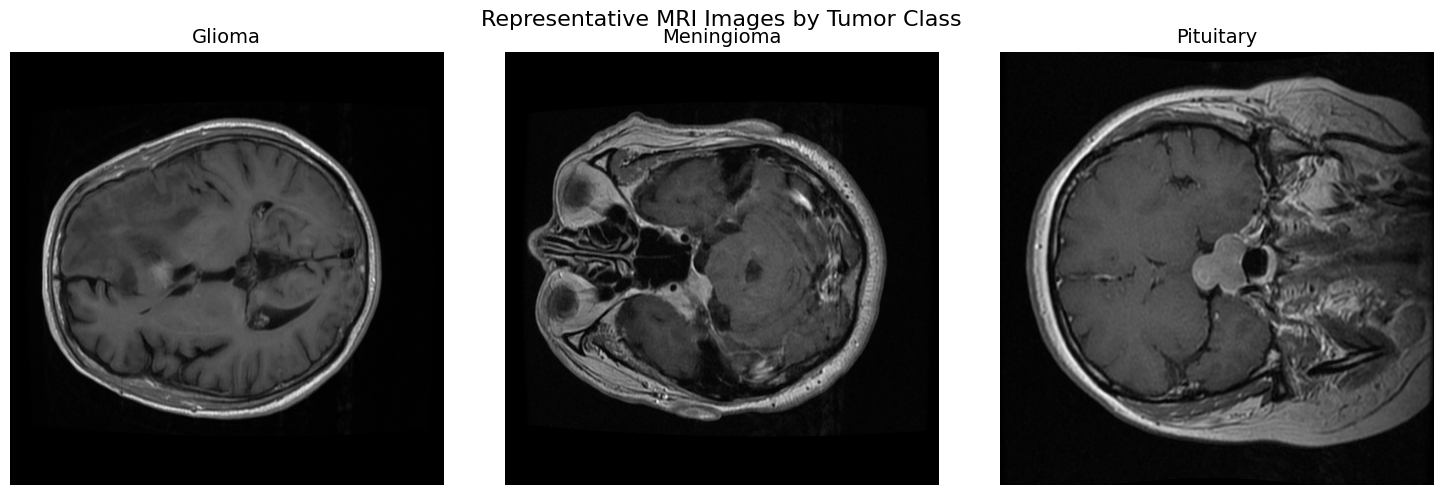

In [171]:
# ============================================================
# SECTION 09.10 — ONE REPRESENTATIVE IMAGE PER CLASS
# ============================================================

display_order = [
    "glioma",
    "meningioma",
    "pituitary"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for ax, diagnosis in zip(axes, display_order):

    sample = (
        train_df[
            train_df["diagnosis"] == diagnosis
        ]
        .iloc[0]
    )

    image, mask = load_mri_from_mat(
        sample["file"]
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        diagnosis.capitalize(),
        fontsize=14
    )

    ax.axis("off")

plt.suptitle(
    "Representative MRI Images by Tumor Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [172]:
# ============================================================
# SECTION 09.11 — PIXEL-LEVEL VIEW
# ============================================================

sample = train_df.iloc[0]

image, mask = load_mri_from_mat(
    sample["file"]
)

print("=" * 60)
print("PIXEL-LEVEL REPRESENTATION")
print("=" * 60)

print(f"\nOriginal image shape : {image.shape}")
print(f"Data type            : {image.dtype}")

print(
    f"\nPixel minimum        : {image.min()}"
)

print(
    f"Pixel maximum        : {image.max()}"
)

print(
    f"Pixel mean           : {image.mean():.2f}"
)

print(
    f"\nFirst 5 × 5 pixels:\n"
)

print(image[:5, :5])

PIXEL-LEVEL REPRESENTATION

Original image shape : (512, 512)
Data type            : int16

Pixel minimum        : 0
Pixel maximum        : 3925
Pixel mean           : 531.02

First 5 × 5 pixels:

[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


#### Computer vision converts visual information into numerical data. A grayscale MRI is represented as a two-dimensional matrix where each value represents pixel intensity. A CNN learns patterns from these numerical values.

### 09.12 — Visualize the Pixel Intensities

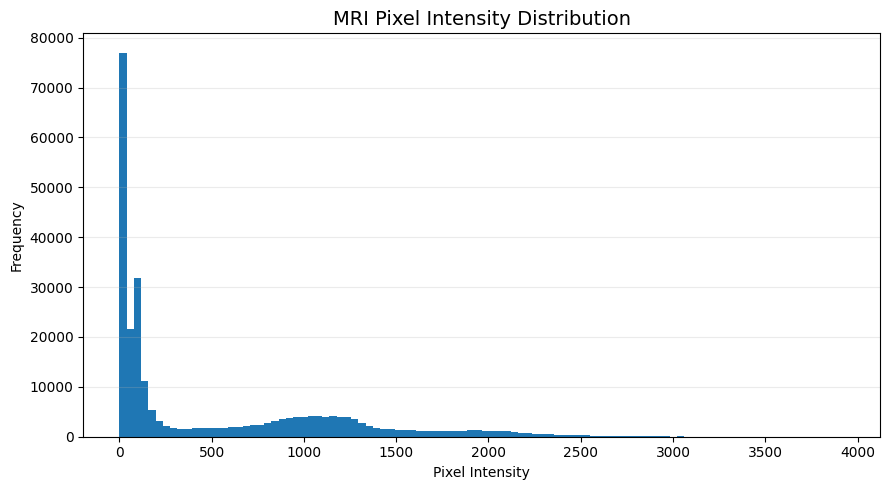

In [173]:
# ============================================================
# SECTION 09.12 — MRI INTENSITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    image.flatten(),
    bins=100
)

plt.title(
    "MRI Pixel Intensity Distribution",
    fontsize=14
)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 09.13 — Tumor Mask Visualization

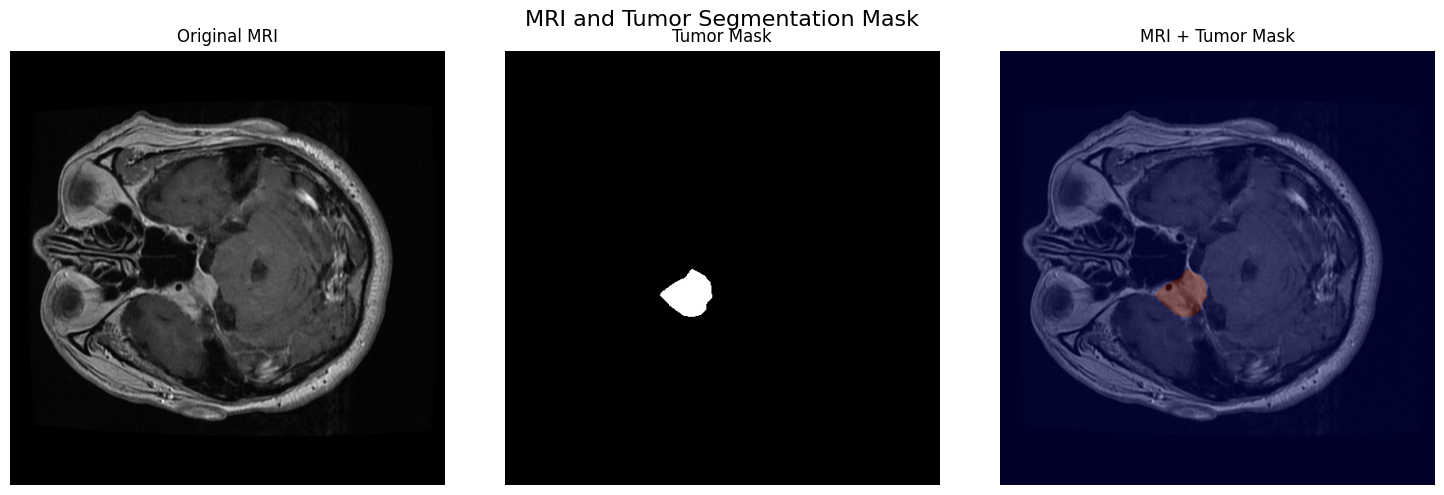

In [174]:
# ============================================================
# SECTION 09.13 — MRI + TUMOR MASK
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    image,
    cmap="gray"
)

axes[0].set_title("Original MRI")

axes[1].imshow(
    mask,
    cmap="gray"
)

axes[1].set_title("Tumor Mask")

axes[2].imshow(
    image,
    cmap="gray"
)

axes[2].imshow(
    mask,
    cmap="jet",
    alpha=0.35
)

axes[2].set_title(
    "MRI + Tumor Mask"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    "MRI and Tumor Segmentation Mask",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### The dataset contains tumor masks in addition to the MRI images. The mask identifies the tumor region. Although our current assignment is classification rather than segmentation, these masks provide valuable information about the dataset and allow us to visually verify the tumor annotations.

In [175]:
# ============================================================
# SECTION 09.14 — TUMOR MASK SIZE
# ============================================================

print("=" * 60)
print("TUMOR MASK SIZE ANALYSIS")
print("=" * 60)

print(
    metadata_df[
        "mask_nonzero_pixels"
    ].describe()
)

TUMOR MASK SIZE ANALYSIS
count     3064.000000
mean      4421.717363
std       3618.518120
min        163.000000
25%       1706.500000
50%       3365.500000
75%       6058.500000
max      25461.000000
Name: mask_nonzero_pixels, dtype: float64


#### This tells us approximately how many pixels belong to the tumor mask

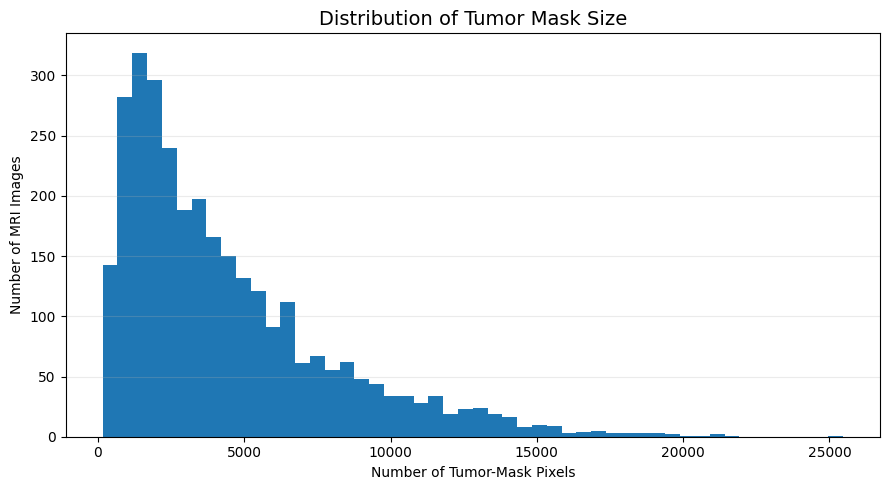

In [176]:
# ============================================================
# SECTION 09.15 — TUMOR MASK SIZE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    metadata_df["mask_nonzero_pixels"],
    bins=50
)

plt.title(
    "Distribution of Tumor Mask Size",
    fontsize=14
)

plt.xlabel("Number of Tumor-Mask Pixels")
plt.ylabel("Number of MRI Images")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [177]:
# ============================================================
# SECTION 09.16 — IMAGE DIMENSIONS
# ============================================================

dimension_counts = (
    metadata_df
    .groupby(
        ["image_height", "image_width"]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print("=" * 60)
print("IMAGE DIMENSION DISTRIBUTION")
print("=" * 60)

print(dimension_counts)

IMAGE DIMENSION DISTRIBUTION
image_height  image_width
512           512            3049
256           256              15
dtype: int64


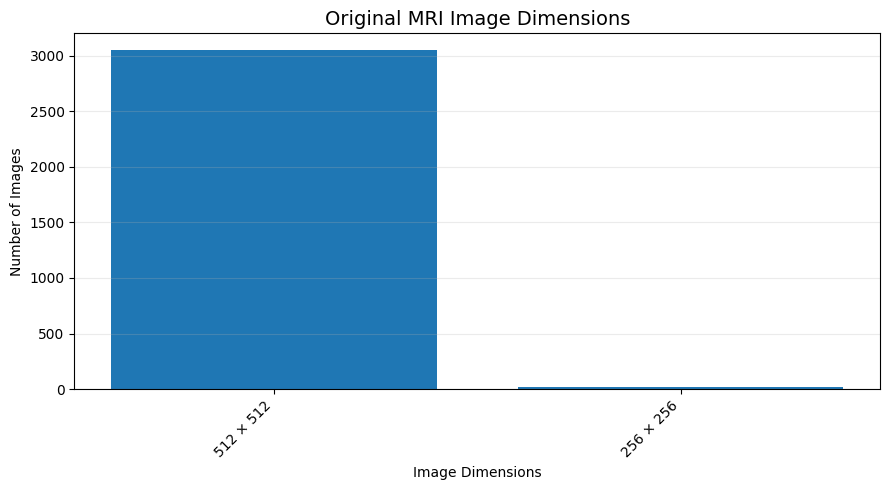

In [178]:
# ============================================================
# SECTION 09.17 — IMAGE DIMENSION VISUALIZATION
# ============================================================

dimension_labels = [
    f"{h} × {w}"
    for h, w in dimension_counts.index
]

plt.figure(figsize=(9, 5))

plt.bar(
    dimension_labels,
    dimension_counts.values
)

plt.title(
    "Original MRI Image Dimensions",
    fontsize=14
)

plt.xlabel("Image Dimensions")
plt.ylabel("Number of Images")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

#### The original dataset does not have completely uniform image dimensions. Most images are 512×512, while a substantial subset is 256×256. This is one reason our preprocessing pipeline standardizes all images to 224×224 before feeding them into the CNN.

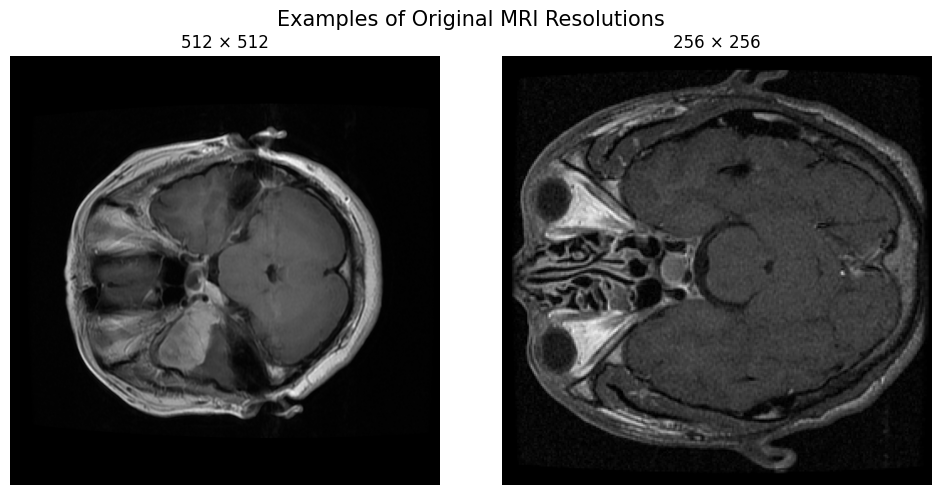

In [179]:
# ============================================================
# SECTION 09.18 — ORIGINAL RESOLUTION COMPARISON
# ============================================================

sizes_to_show = [
    (512, 512),
    (256, 256)
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

for ax, size in zip(
    axes,
    sizes_to_show
):

    h, w = size

    candidates = metadata_df[
        (metadata_df["image_height"] == h) &
        (metadata_df["image_width"] == w)
    ]

    if len(candidates) == 0:
        ax.set_title(
            f"{h} × {w}\nNot available"
        )
        ax.axis("off")
        continue

    sample = candidates.iloc[0]

    img, _ = load_mri_from_mat(
        sample["file"]
    )

    ax.imshow(
        img,
        cmap="gray"
    )

    ax.set_title(
        f"{h} × {w}"
    )

    ax.axis("off")

plt.suptitle(
    "Examples of Original MRI Resolutions",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [180]:
# ============================================================
# SECTION 09.19 — CLASS AND PATIENT SUMMARY
# ============================================================

summary = pd.DataFrame({
    "MRI images": class_counts,
    "Image %": class_percentages.round(2),
    "Patients": patient_class_counts,
    "Patient %": patient_class_percentages.round(2)
})

print("=" * 60)
print("FINAL CLASS ANALYSIS")
print("=" * 60)

print(summary)

FINAL CLASS ANALYSIS
            MRI images  Image %  Patients  Patient %
diagnosis                                           
glioma            1426    46.54        89      38.20
meningioma         708    23.11        82      35.19
pituitary          930    30.35        62      26.61


### 09.20 — Section 09 Final Audit

In [181]:
# ============================================================
# SECTION 09.20 — SECTION SUMMARY
# ============================================================

print("=" * 60)
print("SECTION 09 — EXPLORATORY ANALYSIS COMPLETE")
print("=" * 60)

print("\nDATASET")
print("-" * 60)
print(f"Total MRI images      : {len(metadata_df):,}")
print(f"Unique patients       : {metadata_df['PID'].nunique():,}")
print(f"Number of classes     : {metadata_df['diagnosis'].nunique()}")

print("\nCLASS DISTRIBUTION")
print("-" * 60)

for diagnosis in ["glioma", "meningioma", "pituitary"]:
    count = class_counts[diagnosis]
    percentage = class_percentages[diagnosis]

    print(
        f"{diagnosis:<12}: "
        f"{count:>4,} images "
        f"({percentage:.2f}%)"
    )

print("\nIMAGE PROPERTIES")
print("-" * 60)
print(
    f"Minimum height       : "
    f"{metadata_df['image_height'].min()}"
)
print(
    f"Maximum height       : "
    f"{metadata_df['image_height'].max()}"
)
print(
    f"Minimum width        : "
    f"{metadata_df['image_width'].min()}"
)
print(
    f"Maximum width        : "
    f"{metadata_df['image_width'].max()}"
)

print("\nTUMOR MASK")
print("-" * 60)
print(
    f"Empty masks          : "
    f"{(metadata_df['mask_nonzero_pixels'] == 0).sum()}"
)
print(
    f"Mean mask pixels     : "
    f"{metadata_df['mask_nonzero_pixels'].mean():.2f}"
)

print("\nCONCLUSION")
print("-" * 60)
print("✓ MRI images visually inspected")
print("✓ Class distribution analyzed")
print("✓ Patient distribution analyzed")
print("✓ Image resolution analyzed")
print("✓ Pixel intensity distribution analyzed")
print("✓ Tumor masks visually inspected")
print("✓ Tumor size variation analyzed")

print("\nSECTION 09 COMPLETE.")

SECTION 09 — EXPLORATORY ANALYSIS COMPLETE

DATASET
------------------------------------------------------------
Total MRI images      : 3,064
Unique patients       : 233
Number of classes     : 3

CLASS DISTRIBUTION
------------------------------------------------------------
glioma      : 1,426 images (46.54%)
meningioma  :  708 images (23.11%)
pituitary   :  930 images (30.35%)

IMAGE PROPERTIES
------------------------------------------------------------
Minimum height       : 256
Maximum height       : 512
Minimum width        : 256
Maximum width        : 512

TUMOR MASK
------------------------------------------------------------
Empty masks          : 0
Mean mask pixels     : 4421.72

CONCLUSION
------------------------------------------------------------
✓ MRI images visually inspected
✓ Class distribution analyzed
✓ Patient distribution analyzed
✓ Image resolution analyzed
✓ Pixel intensity distribution analyzed
✓ Tumor masks visually inspected
✓ Tumor size variation analyzed


# SECTION 10 — CNN Architecture & How Convolution Learns Tumor Features

## SECTION 10 — CNN Architecture & How Convolution Learns Tumor Features

In this section, we build the Convolutional Neural Network (CNN) that will classify
brain MRI images into three tumor categories:

- **Glioma**
- **Meningioma**
- **Pituitary**

### What is a CNN?

A Convolutional Neural Network is a deep learning model designed especially for
image data.

Instead of manually defining which visual features are important, a CNN learns
useful features automatically during training.

The learning process can be summarized as:

**MRI Image → Convolution → Feature Extraction → Classification**

Early layers learn simple visual patterns such as edges and intensity changes.
Deeper layers combine these patterns into more complex representations that help
the model distinguish between tumor classes.

### Our CNN

Our model will use:

1. Convolutional layers — learn visual features
2. ReLU activation — introduces non-linearity
3. Max Pooling — reduces spatial dimensions
4. Global Average Pooling — creates a compact feature representation
5. Dense layer — combines learned features
6. Dropout — helps reduce overfitting
7. Softmax output — produces probabilities for the three classes

 

### 10.1 — CNN Configuration

Our preprocessing pipeline converts every MRI into a standard tensor of:

**224 × 224 × 1**

The final `1` represents the grayscale channel.

Because our task has three tumor classes, the CNN will produce three output
probabilities.

In [182]:
# ============================================================
# SECTION 10.1 — CNN CONFIGURATION
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 1

INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "pituitary"
]

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("CNN CONFIGURATION")
print("=" * 60)

print(f"Input shape : {INPUT_SHAPE}")
print(f"Classes     : {CLASS_NAMES}")
print(f"Number of classes : {NUM_CLASSES}")

CNN CONFIGURATION
Input shape : (224, 224, 1)
Classes     : ['glioma', 'meningioma', 'pituitary']
Number of classes : 3


## 10.2 — Understanding Convolution

### 10.2 — How Does Convolution Work?

Convolution is the main operation used by a CNN to extract visual features.

A small matrix called a **filter** or **kernel** moves across the image.

At each position, the filter interacts with a small region of the image and
produces a value.

Repeating this operation across the image produces a **feature map**.

Conceptually:

**Image + Filter → Feature Map**

Different filters can learn to respond to different visual patterns.

For example, some learned filters may respond strongly to edges, boundaries,
textures, or intensity patterns.

The important point is that the CNN **learns these filters automatically during
training** rather than us manually defining them.

In [183]:
# ============================================================
# SECTION 10.2 — SIMPLE CONVOLUTION DEMONSTRATION
# ============================================================

import numpy as np

# Small example image
example_image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1]
], dtype=np.float32)

# Example filter
example_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

print("Example image:")
print(example_image)

print("\nExample filter:")
print(example_filter)

Example image:
[[1. 1. 1. 0. 0.]
 [0. 1. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 1. 0.]
 [0. 0. 0. 1. 1.]]

Example filter:
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


## 10.3 — Create the CNN

### 10.3 — Build the CNN

We now create our CNN architecture.

The number of filters increases from **32 → 64 → 128**.

This allows the network to learn increasingly rich feature representations.

The spatial dimensions are reduced through pooling while the number of learned
features increases.

In [184]:
# ============================================================
# SECTION 10.3 — BUILD CNN MODEL
# ============================================================

model = keras.Sequential([

    # Input
    layers.Input(shape=INPUT_SHAPE),

    # Convolution Block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Classification head
    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.40),

    # Output
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("CNN model created successfully.")

CNN model created successfully.


## 10.4 — Inspect the Architecture

### 10.4 — CNN Architecture Summary

The model progressively transforms the MRI from raw pixels into learned
representations.

The convolutional layers learn visual features, while pooling reduces the
spatial dimensions.

Finally, the classification head uses the learned representation to predict
one of the three tumor classes.

In [236]:
# ============================================================
# SECTION 10.4 — MODEL SUMMARY
# ============================================================

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,715 (1.25 MB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 219,144 (856.04 KB)

## 10.5 — Understand the Main CNN Components

## 10.5 — Understanding the Main CNN Components

### Convolution

Convolution applies learnable filters to the image to detect useful visual
patterns.

### ReLU

ReLU is an activation function:

**ReLU(x) = max(0, x)**

It introduces non-linearity, allowing the network to learn more complex
relationships.

### Max Pooling

Max pooling reduces the spatial dimensions of feature maps while retaining
strong activations.

For example:

**224 × 224 → 112 × 112**

This reduces computation and helps the network focus on important features.

### Global Average Pooling

Global Average Pooling converts the final feature maps into a compact vector
before classification.

### Dropout

Dropout temporarily removes a fraction of neurons during training. We use it
to help reduce overfitting.

### Softmax

The final Softmax layer converts the network's outputs into probabilities for
our three classes:

- Glioma
- Meningioma
- Pituitary

## 10.6 — Compile the CNN

### 10.6 — Compile the CNN

Before training, we specify how the CNN should learn.

We use:

- **Adam** as the optimizer
- **Sparse categorical crossentropy** as the loss function
- **Accuracy** as a performance metric

The optimizer updates the model's learnable weights based on the error produced
during training.

In [186]:
# ============================================================
# SECTION 10.6 — COMPILE CNN
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 60)
print("CNN COMPILED")
print("=" * 60)

print("Optimizer : Adam")
print("Loss      : Sparse Categorical Crossentropy")
print("Metric    : Accuracy")

CNN COMPILED
Optimizer : Adam
Loss      : Sparse Categorical Crossentropy
Metric    : Accuracy


## 10.7 — The Learning Process

## 10.7 — How Will the CNN Learn?

The CNN learns through repeated forward and backward passes.

### Forward pass

The MRI passes through the CNN and produces class probabilities.

### Loss calculation

The predicted probabilities are compared with the correct class.

### Backpropagation

The error is propagated backward through the network.

### Weight update

The optimizer adjusts the model's learnable weights.

This process repeats over many training examples.

Therefore:

**MRI → Prediction → Loss → Backpropagation → Weight Update**

After many iterations, the CNN should learn increasingly useful representations
for distinguishing the three tumor classes.

> Important: We are training a research/academic image-classification model.
> Its predictions should not be interpreted as a clinical diagnosis.

## 10.8 — Final Architecture Verification

In [187]:
# ============================================================
# SECTION 10.8 — ARCHITECTURE VERIFICATION
# ============================================================

print("=" * 60)
print("CNN ARCHITECTURE VERIFICATION")
print("=" * 60)

print(f"Input shape      : {INPUT_SHAPE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names      : {CLASS_NAMES}")
print(f"Total parameters : {model.count_params():,}")

print("\nArchitecture:")
print("Input")
print("  ↓")
print("Conv2D — 32 filters")
print("  ↓")
print("MaxPooling")
print("  ↓")
print("Conv2D — 64 filters")
print("  ↓")
print("MaxPooling")
print("  ↓")
print("Conv2D — 128 filters")
print("  ↓")
print("MaxPooling")
print("  ↓")
print("GlobalAveragePooling")
print("  ↓")
print("Dense — 128")
print("  ↓")
print("Dropout — 40%")
print("  ↓")
print("Softmax — 3 classes")

print("\n✓ CNN architecture created")
print("✓ CNN compiled")
print("✓ Ready for training")

CNN ARCHITECTURE VERIFICATION
Input shape      : (224, 224, 1)
Number of classes: 3
Class names      : ['glioma', 'meningioma', 'pituitary']
Total parameters : 109,571

Architecture:
Input
  ↓
Conv2D — 32 filters
  ↓
MaxPooling
  ↓
Conv2D — 64 filters
  ↓
MaxPooling
  ↓
Conv2D — 128 filters
  ↓
MaxPooling
  ↓
GlobalAveragePooling
  ↓
Dense — 128
  ↓
Dropout — 40%
  ↓
Softmax — 3 classes

✓ CNN architecture created
✓ CNN compiled
✓ Ready for training


#### After preprocessing the MRI images, we use a Convolutional Neural Network. CNNs are designed for image data and automatically learn useful visual features. The first convolutional layers learn relatively simple patterns, while deeper layers combine these patterns into richer representations. Pooling reduces the spatial dimensions, and the final classification layer produces probabilities for glioma, meningioma, and pituitary tumor. The model is then trained using backpropagation and the Adam optimizer.

# SECTION 11 — CNN Training & Learning Curves

## SECTION 11 — CNN Training & Learning Curves

In this section, we train our Convolutional Neural Network (CNN) to classify
brain MRI images into three tumor categories:

- Glioma
- Meningioma
- Pituitary tumor

The CNN learns by repeatedly performing four steps:

1. **Forward propagation** — the MRI image passes through the CNN and a prediction is produced.
2. **Loss calculation** — the prediction is compared with the true tumor class.
3. **Backpropagation** — the model determines how its weights contributed to the error.
4. **Weight update** — the optimizer adjusts the weights to reduce future errors.

We train using the training patients only.

The validation set is not used to update the model. It is used to monitor
how well the model generalizes to previously unseen patients.

### What we monitor

- **Training Accuracy** — how well the CNN classifies training images.
- **Validation Accuracy** — how well the CNN classifies unseen validation images.
- **Training Loss** — the model's prediction error on training data.
- **Validation Loss** — the model's prediction error on validation data.

Learning curves help us identify problems such as:

- Underfitting — the model is not learning enough.
- Overfitting — training performance improves while validation performance stops improving or gets worse.
- Good generalization — training and validation performance improve together.

Important:
The test set remains untouched during training and will only be used for
the final evaluation.

In [192]:
# ============================================================
# SECTION 11 — STEP 1
# IMAGE TENSOR DATASET BUILDER
# ============================================================
#
# Purpose:
# Convert the patient-level DataFrame into CNN-ready tensors.
#
# Input:
#   train_df / val_df / test_df
#
# Output:
#   X -> images
#   y -> numerical class labels
#
# CNN input format:
#   (number_of_images, 224, 224, 1)
# ============================================================

import numpy as np
import h5py
from PIL import Image
from pathlib import Path

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

IMAGE_SIZE = (224, 224)

CLASS_NAMES = {
    1: "meningioma",
    2: "glioma",
    3: "pituitary"
}

CLASS_TO_INDEX = {
    "meningioma": 0,
    "glioma": 1,
    "pituitary": 2
}


# ------------------------------------------------------------
# Find the image inside a MAT file
# ------------------------------------------------------------

def load_mri_image(mat_path):
    """
    Load the MRI image from a MATLAB v7.3 MAT file.

    Returns:
        image: 2D NumPy array
    """

    with h5py.File(mat_path, "r") as f:
        image = np.array(f["cjdata"]["image"])

    return image


# ------------------------------------------------------------
# Build CNN tensor dataset
# ------------------------------------------------------------

def build_tensor_dataset(dataframe):

    images = []
    labels = []

    for _, row in dataframe.iterrows():

        # --------------------------------------------
        # Load MRI
        # --------------------------------------------

        image = load_mri_image(row["file"])

        # --------------------------------------------
        # Convert to float32
        # --------------------------------------------

        image = image.astype(np.float32)

        # --------------------------------------------
        # Normalize pixels to [0, 1]
        # --------------------------------------------

        image_min = image.min()
        image_max = image.max()

        if image_max > image_min:
            image = (image - image_min) / (image_max - image_min)
        else:
            image = np.zeros_like(image, dtype=np.float32)

        # --------------------------------------------
        # Resize to CNN input size
        # --------------------------------------------

        image_uint8 = (image * 255).astype(np.uint8)

        pil_image = Image.fromarray(image_uint8)

        pil_image = pil_image.resize(
            IMAGE_SIZE,
            Image.Resampling.BILINEAR
        )

        image = np.asarray(pil_image).astype(np.float32) / 255.0

        # --------------------------------------------
        # Add grayscale channel
        # --------------------------------------------

        image = np.expand_dims(image, axis=-1)

        # --------------------------------------------
        # Convert diagnosis to numerical label
        # --------------------------------------------

        diagnosis = row["diagnosis"]

        label = CLASS_TO_INDEX[diagnosis]

        # --------------------------------------------
        # Store
        # --------------------------------------------

        images.append(image)
        labels.append(label)

    # --------------------------------------------
    # Convert lists → NumPy arrays
    # --------------------------------------------

    X = np.asarray(images, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64)

    return X, y

##  Build CNN Training Tensors

The patient-level split has already been completed.

We now convert the training and validation MRI files into tensors that can
be provided to the CNN.

Each MRI goes through the same preprocessing pipeline:

1. MRI image
    
2. Convert to float32
    
3. Normalize pixel values to [0, 1]
    
4. Resize to 224 × 224
    
5. Add grayscale channel
    
6. CNN input: (224, 224, 1)

Only the training and validation sets are loaded at this stage.

The test set remains untouched until the final evaluation.

In [193]:
# ============================================================
# SECTION 11 — STEP 2
# BUILD CNN TRAINING AND VALIDATION TENSORS
# ============================================================

print("=" * 60)
print("BUILDING CNN TRAINING AND VALIDATION TENSORS")
print("=" * 60)

# Training data
X_train, y_train = build_tensor_dataset(train_df)

# Validation data
X_val, y_val = build_tensor_dataset(val_df)

# Test data will remain untouched until final evaluation
# and will be created later.

print()
print("TRAINING DATA")
print("-" * 60)
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

print()
print("VALIDATION DATA")
print("-" * 60)
print(f"X_val shape   : {X_val.shape}")
print(f"y_val shape   : {y_val.shape}")

BUILDING CNN TRAINING AND VALIDATION TENSORS

TRAINING DATA
------------------------------------------------------------
X_train shape : (1793, 224, 224, 1)
y_train shape : (1793,)

VALIDATION DATA
------------------------------------------------------------
X_val shape   : (628, 224, 224, 1)
y_val shape   : (628,)


### 11.3 Label Encoding & Tensor Validation

The CNN cannot directly learn from text labels such as `"glioma"` or
`"meningioma"`. We therefore represent the three tumor categories using
integer class labels.

Our fixed mapping is:

| Class | Label |
|---|---:|
| Meningioma | 0 |
| Glioma | 1 |
| Pituitary | 2 |

The encoding is applied consistently to training, validation, and test data.

Before training, we verify:

- image tensor shapes
- data type
- pixel range
- label values
- label-to-diagnosis mapping
- number of samples

In [194]:
# ============================================================
# SECTION 11 — STEP 3
# LABEL ENCODING & TENSOR VALIDATION
# ============================================================

print("=" * 60)
print("LABEL ENCODING & TENSOR VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Fixed class mapping
# ------------------------------------------------------------

CLASS_NAMES = [
    "meningioma",
    "glioma",
    "pituitary"
]

CLASS_TO_INDEX = {
    "meningioma": 0,
    "glioma": 1,
    "pituitary": 2
}

INDEX_TO_CLASS = {
    0: "meningioma",
    1: "glioma",
    2: "pituitary"
}

# ------------------------------------------------------------
# Display mapping
# ------------------------------------------------------------

print("\nCLASS ENCODING")
print("-" * 60)

for class_name, index in CLASS_TO_INDEX.items():
    print(f"{class_name:<15} → {index}")

# ------------------------------------------------------------
# Validate labels
# ------------------------------------------------------------

print("\nLABEL VALIDATION")
print("-" * 60)

print("Training unique labels   :", np.unique(y_train))
print("Validation unique labels :", np.unique(y_val))

assert set(np.unique(y_train)) == {0, 1, 2}
assert set(np.unique(y_val)) == {0, 1, 2}

print("✓ All three classes are present.")

# ------------------------------------------------------------
# Validate tensor shapes
# ------------------------------------------------------------

print("\nIMAGE TENSOR VALIDATION")
print("-" * 60)

print("Training shape   :", X_train.shape)
print("Validation shape :", X_val.shape)

assert X_train.ndim == 4
assert X_val.ndim == 4

assert X_train.shape[1:] == (224, 224, 1)
assert X_val.shape[1:] == (224, 224, 1)

print("✓ CNN-compatible tensor shape confirmed.")

# ------------------------------------------------------------
# Validate data types
# ------------------------------------------------------------

print("\nDATA TYPE VALIDATION")
print("-" * 60)

print("X_train :", X_train.dtype)
print("X_val   :", X_val.dtype)
print("y_train :", y_train.dtype)
print("y_val   :", y_val.dtype)

assert X_train.dtype == np.float32
assert X_val.dtype == np.float32

print("✓ Image tensors use float32.")

# ------------------------------------------------------------
# Validate pixel range
# ------------------------------------------------------------

print("\nPIXEL RANGE VALIDATION")
print("-" * 60)

print(f"Training minimum : {X_train.min():.4f}")
print(f"Training maximum : {X_train.max():.4f}")

print(f"Validation minimum : {X_val.min():.4f}")
print(f"Validation maximum : {X_val.max():.4f}")

assert X_train.min() >= 0.0
assert X_train.max() <= 1.0

assert X_val.min() >= 0.0
assert X_val.max() <= 1.0

print("✓ Pixel values are normalized to [0, 1].")

# ------------------------------------------------------------
# Validate sample counts
# ------------------------------------------------------------

print("\nSAMPLE COUNT VALIDATION")
print("-" * 60)

print("Training images   :", len(X_train))
print("Training labels   :", len(y_train))

print("Validation images :", len(X_val))
print("Validation labels :", len(y_val))

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)

print("✓ Image/label counts match.")

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("✓ LABEL & TENSOR VALIDATION PASSED")
print("=" * 60)

LABEL ENCODING & TENSOR VALIDATION

CLASS ENCODING
------------------------------------------------------------
meningioma      → 0
glioma          → 1
pituitary       → 2

LABEL VALIDATION
------------------------------------------------------------
Training unique labels   : [0 1 2]
Validation unique labels : [0 1 2]
✓ All three classes are present.

IMAGE TENSOR VALIDATION
------------------------------------------------------------
Training shape   : (1793, 224, 224, 1)
Validation shape : (628, 224, 224, 1)
✓ CNN-compatible tensor shape confirmed.

DATA TYPE VALIDATION
------------------------------------------------------------
X_train : float32
X_val   : float32
y_train : int64
y_val   : int64
✓ Image tensors use float32.

PIXEL RANGE VALIDATION
------------------------------------------------------------
Training minimum : 0.0000
Training maximum : 0.9843
Validation minimum : 0.0000
Validation maximum : 0.9804
✓ Pixel values are normalized to [0, 1].

SAMPLE COUNT VALIDATION
---

### 11.4 Training Class Distribution

Although the dataset is reasonably balanced compared with many medical
datasets, the classes are not identical in size.

We therefore inspect the class distribution after the patient-level split.

This is important because a CNN trained on imbalanced data may learn to
favor the more frequently represented class.

We will use the training distribution to decide whether class weighting
is appropriate.

In [195]:
# ============================================================
# SECTION 11 — STEP 4
# TRAINING CLASS DISTRIBUTION
# ============================================================

from collections import Counter

print("=" * 60)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 60)

train_counts = Counter(y_train)
val_counts = Counter(y_val)

print("\nTRAINING")
print("-" * 60)

for index in range(len(CLASS_NAMES)):
    count = train_counts[index]
    percentage = count / len(y_train) * 100

    print(
        f"{CLASS_NAMES[index]:<15} : "
        f"{count:4d} images ({percentage:5.2f}%)"
    )

print("\nVALIDATION")
print("-" * 60)

for index in range(len(CLASS_NAMES)):
    count = val_counts[index]
    percentage = count / len(y_val) * 100

    print(
        f"{CLASS_NAMES[index]:<15} : "
        f"{count:4d} images ({percentage:5.2f}%)"
    )

TRAINING CLASS DISTRIBUTION

TRAINING
------------------------------------------------------------
meningioma      :  418 images (23.31%)
glioma          :  814 images (45.40%)
pituitary       :  561 images (31.29%)

VALIDATION
------------------------------------------------------------
meningioma      :  124 images (19.75%)
glioma          :  325 images (51.75%)
pituitary       :  179 images (28.50%)


### 11.5 Class Imbalance Handling

The training data is not perfectly balanced.

Glioma represents the largest class, while meningioma is the smallest.
However, the imbalance is moderate rather than extreme.

Instead of duplicating images or artificially changing the dataset, we use
class weights. Class weighting gives slightly more importance to samples
from smaller classes during training.

The weights are calculated using only the training labels.

This is important because the validation and test sets must remain untouched.

In [196]:
# ============================================================
# SECTION 11 — STEP 5
# CLASS IMBALANCE HANDLING
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Calculate balanced class weights
# ------------------------------------------------------------

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(classes, class_weights_array)
}

# ------------------------------------------------------------
# Display weights
# ------------------------------------------------------------

print("\nCLASS WEIGHTS")
print("-" * 60)

for class_index in classes:
    print(
        f"{CLASS_NAMES[class_index]:<15} : "
        f"{class_weights[class_index]:.4f}"
    )

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

assert set(class_weights.keys()) == {0, 1, 2}
assert all(weight > 0 for weight in class_weights.values())

print("\n✓ Class weights calculated successfully.")

CLASS IMBALANCE ANALYSIS

CLASS WEIGHTS
------------------------------------------------------------
meningioma      : 1.4298
glioma          : 0.7342
pituitary       : 1.0654

✓ Class weights calculated successfully.


## 11.6 Train the CNN

### 11.7 CNN Training

The CNN architecture was created and compiled in Section 10.

In this step, we train that existing CNN using:

- Training MRI images (`X_train`)
- Training labels (`y_train`)
- Validation MRI images (`X_val`)
- Validation labels (`y_val`)
- Class weights calculated from the training distribution

### Why validation data?

The model learns from the training images, while the validation set
provides an independent check during training.

This allows us to monitor whether the CNN is learning useful patterns
or simply memorizing the training images.

### Why class weights?

The three tumor classes are not perfectly balanced.

Class weights give slightly more importance to the underrepresented
classes and prevent the CNN from being overly influenced by the largest class.

The test set remains completely untouched during training.

In [213]:
# ============================================================
# SECTION 11 — FINAL CNN TRAINING
# ============================================================

import tensorflow as tf

print("=" * 60)
print("FINAL CNN TRAINING")
print("=" * 60)

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 30
BATCH_SIZE = 32

print("\nTraining configuration")
print("-" * 60)
print(f"Maximum epochs : {EPOCHS}")
print(f"Batch size     : {BATCH_SIZE}")
print("Optimizer      : Adam")
print("Loss           : Sparse Categorical Crossentropy")
print("Classes        : 3")
print("Class weights  : Enabled")
print("Early stopping : Enabled")
print("Checkpoint     : Enabled")
print("Restore best  : Enabled")

# ------------------------------------------------------------
# Save the model whenever validation loss improves
# ------------------------------------------------------------

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_brain_tumor_cnn.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

# ------------------------------------------------------------
# Stop when validation loss stops improving
# ------------------------------------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# Train CNN
# ------------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    shuffle=True,
    callbacks=[
        checkpoint,
        early_stopping
    ],
    verbose=1
)

print("\n" + "=" * 60)
print("✓ FINAL CNN TRAINING COMPLETE")
print("=" * 60)

print(f"\nEpochs actually completed : {len(history.history['loss'])}")
print(
    f"Best validation accuracy : "
    f"{max(history.history['val_accuracy']) * 100:.2f}%"
)
print(
    f"Best validation loss     : "
    f"{min(history.history['val_loss']):.4f}"
)

FINAL CNN TRAINING

Training configuration
------------------------------------------------------------
Maximum epochs : 30
Batch size     : 32
Optimizer      : Adam
Loss           : Sparse Categorical Crossentropy
Classes        : 3
Class weights  : Enabled
Early stopping : Enabled
Checkpoint     : Enabled
Restore best  : Enabled
Epoch 1/30
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7202 - loss: 0.6172
Epoch 1: val_loss improved from None to 0.71112, saving model to best_brain_tumor_cnn.keras

Epoch 1: finished saving model to best_brain_tumor_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7340 - loss: 0.5925 - val_accuracy: 0.6529 - val_loss: 0.7111
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6932 - loss: 0.6516
Epoch 2: val_loss improved from 0.71112 to 0.70452, saving model to best_brain_tumor_cnn.keras

Epoch 2: finished saving model to best_brain_tumor_cnn.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7228 - loss: 0.6

In [214]:
# ============================================================
# VERIFY FINAL BEST MODEL
# ============================================================

import os

print("=" * 60)
print("BEST MODEL CHECKPOINT VERIFICATION")
print("=" * 60)

MODEL_PATH = "best_brain_tumor_cnn.keras"

if os.path.exists(MODEL_PATH):
    print(f"\n✓ Checkpoint found: {MODEL_PATH}")

    best_model = tf.keras.models.load_model(MODEL_PATH)

    print("✓ Best model loaded successfully")

    print("\nModel input shape  :", best_model.input_shape)
    print("Model output shape :", best_model.output_shape)
else:
    print("\n✗ Checkpoint not found")

BEST MODEL CHECKPOINT VERIFICATION

✓ Checkpoint found: best_brain_tumor_cnn.keras
✓ Best model loaded successfully

Model input shape  : (None, 224, 224, 1)
Model output shape : (None, 3)


## 11.7 Analyze Training History

### 11.7 Analyze Training History

During training, Keras recorded the performance of the CNN after every epoch.

The training history contains four important measurements:

- **Training accuracy** — how well the CNN predicts the training images.
- **Validation accuracy** — how well it predicts unseen validation images.
- **Training loss** — how much error the model makes on training data.
- **Validation loss** — how much error it makes on validation data.

We compare these values across epochs to understand how the CNN learned.

### What are we looking for?

A healthy training process generally shows:

- Training loss decreasing
- Validation loss decreasing or remaining reasonably stable
- Training accuracy increasing
- Validation accuracy increasing or remaining reasonably stable

If training accuracy continues increasing while validation accuracy stops
improving or validation loss increases, this can indicate **overfitting**.

The learning curves in the next steps will make this behavior easier to see visually.

In [215]:
# ============================================================
# SECTION 11 — STEP 7
# ANALYZE TRAINING HISTORY
# ============================================================

print("=" * 60)
print("TRAINING HISTORY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Extract recorded metrics
# ------------------------------------------------------------

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# ------------------------------------------------------------
# Number of epochs
# ------------------------------------------------------------

num_epochs = len(train_accuracy)

print(f"\nTotal epochs completed : {num_epochs}")

# ------------------------------------------------------------
# Best validation accuracy
# ------------------------------------------------------------

best_val_accuracy_epoch = (
    int(np.argmax(val_accuracy)) + 1
)

best_val_accuracy = max(val_accuracy)

print("\nBEST VALIDATION ACCURACY")
print("-" * 60)
print(f"Epoch    : {best_val_accuracy_epoch}")
print(f"Accuracy : {best_val_accuracy:.4f}")
print(f"Accuracy : {best_val_accuracy * 100:.2f}%")

# ------------------------------------------------------------
# Best validation loss
# ------------------------------------------------------------

best_val_loss_epoch = (
    int(np.argmin(val_loss)) + 1
)

best_val_loss = min(val_loss)

print("\nBEST VALIDATION LOSS")
print("-" * 60)
print(f"Epoch : {best_val_loss_epoch}")
print(f"Loss  : {best_val_loss:.4f}")

# ------------------------------------------------------------
# Final epoch
# ------------------------------------------------------------

print("\nFINAL EPOCH")
print("-" * 60)
print(f"Training accuracy   : {train_accuracy[-1]:.4f}")
print(f"Validation accuracy : {val_accuracy[-1]:.4f}")
print(f"Training loss       : {train_loss[-1]:.4f}")
print(f"Validation loss     : {val_loss[-1]:.4f}")

print("\n" + "=" * 60)
print("✓ TRAINING HISTORY ANALYZED")
print("=" * 60)

TRAINING HISTORY ANALYSIS

Total epochs completed : 19

BEST VALIDATION ACCURACY
------------------------------------------------------------
Epoch    : 9
Accuracy : 0.7309
Accuracy : 73.09%

BEST VALIDATION LOSS
------------------------------------------------------------
Epoch : 14
Loss  : 0.5320

FINAL EPOCH
------------------------------------------------------------
Training accuracy   : 0.7758
Validation accuracy : 0.7102
Training loss       : 0.5056
Validation loss     : 0.5757

✓ TRAINING HISTORY ANALYZED


## 11.8 Accuracy Learning Curve

### 11.8 Accuracy Learning Curve

The accuracy learning curve shows how the CNN's classification accuracy
changed during training.

We plot two curves:

- **Training Accuracy** — performance on images used to train the CNN.
- **Validation Accuracy** — performance on images not used to update the
  model's weights.

### Why is this useful?

The two curves allow us to visually understand whether the CNN is
generalizing to unseen MRI images.

We are especially interested in:

- whether accuracy improves with training,
- whether validation accuracy follows training accuracy,
- where the best validation performance occurs,
- and whether a gap develops between training and validation accuracy.

This is one of the main tools we use to identify overfitting.

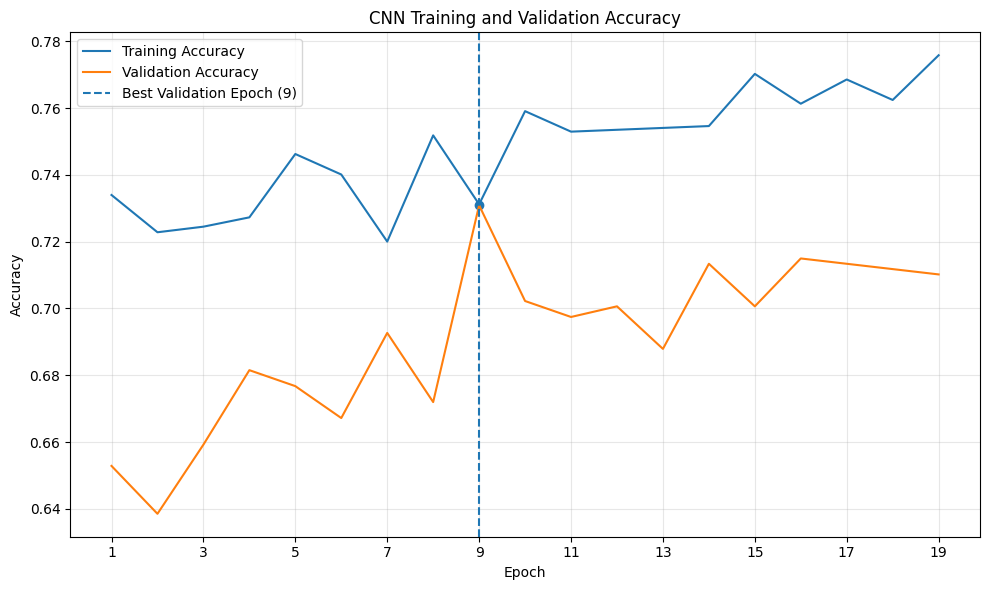

ACCURACY LEARNING CURVE
Best validation accuracy : 0.7309
Best validation epoch    : 9


In [216]:
# ============================================================
# SECTION 11 — STEP 8
# ACCURACY LEARNING CURVE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

epochs_range = range(1, len(train_accuracy) + 1)

best_epoch = np.argmax(val_accuracy) + 1
best_accuracy = max(val_accuracy)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracy,
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Validation Epoch ({best_epoch})"
)

plt.scatter(
    best_epoch,
    best_accuracy
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(train_accuracy) + 1, 2))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("ACCURACY LEARNING CURVE")
print("=" * 60)
print(f"Best validation accuracy : {best_accuracy:.4f}")
print(f"Best validation epoch    : {best_epoch}")

## 11.9 Loss Learning Curve

### 11.9 Loss Learning Curve

Loss measures how far the CNN's predictions are from the correct labels.

Unlike accuracy, which tells us the percentage of correct predictions,
loss gives us a measure of the model's prediction error.

We plot:

- **Training Loss** — error on the training MRI images.
- **Validation Loss** — error on the validation MRI images.

### What are we looking for?

A healthy learning process generally shows both training and validation
loss decreasing.

If training loss continues decreasing while validation loss starts
increasing, the model may be **overfitting**.

The point where validation loss is lowest is especially useful because
it represents the epoch where the model performed best according to
the loss metric.

We will combine this graph with the accuracy curve to make our final
overfitting/underfitting assessment.

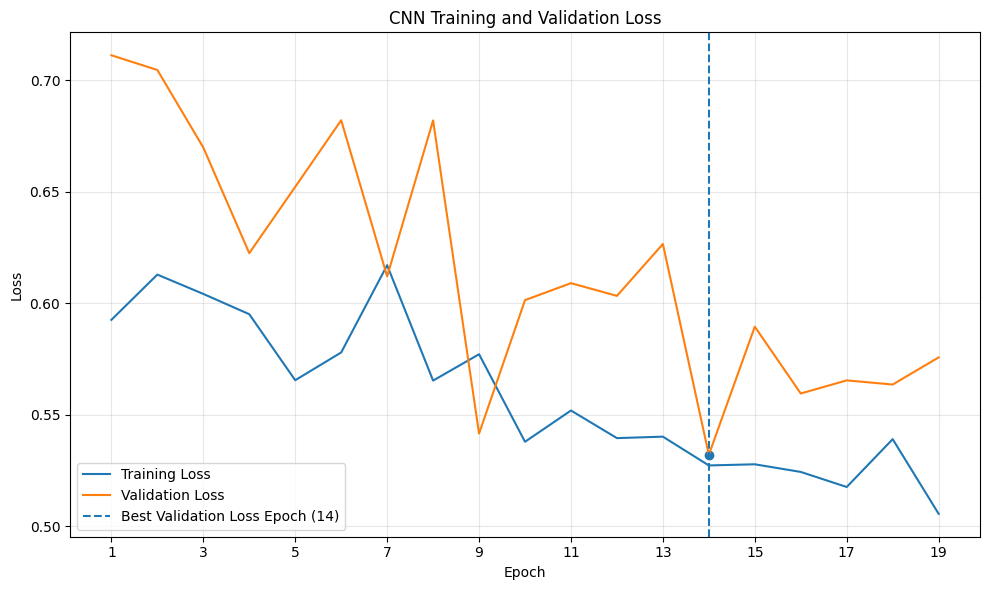

LOSS LEARNING CURVE
Lowest validation loss : 0.5320
Best validation epoch  : 14


In [217]:
# ============================================================
# SECTION 11 — STEP 9
# LOSS LEARNING CURVE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

epochs_range = range(1, len(train_loss) + 1)

# Find the epoch with the lowest validation loss
best_loss_epoch = np.argmin(val_loss) + 1
best_loss = min(val_loss)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.axvline(
    best_loss_epoch,
    linestyle="--",
    label=f"Best Validation Loss Epoch ({best_loss_epoch})"
)

plt.scatter(
    best_loss_epoch,
    best_loss
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, len(train_loss) + 1, 2))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("LOSS LEARNING CURVE")
print("=" * 60)
print(f"Lowest validation loss : {best_loss:.4f}")
print(f"Best validation epoch  : {best_loss_epoch}")

## 11.10 — Overfitting / Underfitting Analysis

### 11.10 — Overfitting / Underfitting Analysis

### Why do we analyze overfitting?

A CNN can perform well on the training images but poorly on new images.

This is called **overfitting**.

Our goal is not simply to memorize the training MRI scans.  
We want the CNN to learn useful visual patterns that generalize to MRI scans from patients it has never seen.

### How do we identify overfitting?

We compare training and validation performance.

#### Signs of underfitting

- Training accuracy is low.
- Validation accuracy is also low.
- Training and validation performance are both poor.

This means the model has not learned enough useful patterns.

#### Signs of overfitting

- Training accuracy continues increasing.
- Training loss continues decreasing.
- Validation accuracy stops improving or becomes unstable.
- Validation loss starts increasing.

This means the model may be learning the training data too specifically.

The learning curves show that the CNN learned useful patterns during training, but
validation performance became unstable during the later epochs.

Therefore, we should select the model based on validation performance rather than
automatically using the final epoch.

### Important conclusion

Our first CNN is learning, but it is not yet highly stable.

This is useful information rather than a failure.

In the next stages, we will evaluate the model on the completely unseen
**test patients** and determine how well it generalizes to new MRI scans.

In [218]:
# ============================================================
# SECTION 11.10 — OVERFITTING / UNDERFITTING ANALYSIS
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Extract training history
# ------------------------------------------------------------

train_acc = np.array(history.history["accuracy"])
val_acc = np.array(history.history["val_accuracy"])

train_loss = np.array(history.history["loss"])
val_loss = np.array(history.history["val_loss"])

epochs = np.arange(1, len(train_acc) + 1)

# ------------------------------------------------------------
# 2. Find best validation epoch
# ------------------------------------------------------------

best_val_acc_epoch = np.argmax(val_acc) + 1
best_val_acc = np.max(val_acc)

best_val_loss_epoch = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

# ------------------------------------------------------------
# 3. Final epoch
# ------------------------------------------------------------

final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]

final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# ------------------------------------------------------------
# 4. Generalization gaps
# ------------------------------------------------------------

accuracy_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

print("=" * 60)
print("OVERFITTING / UNDERFITTING ANALYSIS")
print("=" * 60)

print("\nBEST VALIDATION PERFORMANCE")
print("-" * 60)
print(f"Best validation accuracy : {best_val_acc:.4f}")
print(f"Best validation accuracy : {best_val_acc * 100:.2f}%")
print(f"Epoch                    : {best_val_acc_epoch}")

print(f"\nBest validation loss     : {best_val_loss:.4f}")
print(f"Epoch                    : {best_val_loss_epoch}")

print("\nFINAL EPOCH")
print("-" * 60)
print(f"Training accuracy        : {final_train_acc:.4f}")
print(f"Validation accuracy      : {final_val_acc:.4f}")
print(f"Training loss            : {final_train_loss:.4f}")
print(f"Validation loss          : {final_val_loss:.4f}")

print("\nGENERALIZATION GAP")
print("-" * 60)
print(f"Accuracy gap             : {accuracy_gap:.4f}")
print(f"Accuracy gap             : {accuracy_gap * 100:.2f} percentage points")
print(f"Loss gap                 : {loss_gap:.4f}")

print("\nINTERPRETATION")
print("-" * 60)

if accuracy_gap > 0.10 and loss_gap > 0:
    print("⚠ Evidence of overfitting.")
elif final_train_acc < 0.70 and final_val_acc < 0.70:
    print("⚠ Model may still be underfitting.")
else:
    print("✓ Model is learning, with some generalization gap.")

print("\n" + "=" * 60)

OVERFITTING / UNDERFITTING ANALYSIS

BEST VALIDATION PERFORMANCE
------------------------------------------------------------
Best validation accuracy : 0.7309
Best validation accuracy : 73.09%
Epoch                    : 9

Best validation loss     : 0.5320
Epoch                    : 14

FINAL EPOCH
------------------------------------------------------------
Training accuracy        : 0.7758
Validation accuracy      : 0.7102
Training loss            : 0.5056
Validation loss          : 0.5757

GENERALIZATION GAP
------------------------------------------------------------
Accuracy gap             : 0.0656
Accuracy gap             : 6.56 percentage points
Loss gap                 : 0.0701

INTERPRETATION
------------------------------------------------------------
✓ Model is learning, with some generalization gap.



# SECTION 12 — TEST SET EVALUATION & GENERALIZATION

## 12.1 — Prepare the Test Set

The test set contains MRI images from patients that were not used during
CNN training or validation.

We will now apply the exact same image preparation pipeline used for
training and validation:

1. MAT file
   
2. MRI image
   
3. Convert to float32
   
4. Normalize pixels to [0, 1]
   
5. Resize to 224 × 224
   
6. Add grayscale channel
   
7. CNN-compatible tensor

Important:
No data augmentation is applied to the test set.

The test images must represent the original unseen data as fairly as possible.

In [202]:
# ============================================================
# SECTION 12.1 — BUILD TEST TENSORS
# ============================================================

print("=" * 60)
print("BUILDING TEST TENSORS")
print("=" * 60)

X_test, y_test = build_tensor_dataset(test_df)

print("\nTEST DATA")
print("-" * 60)
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

print("\nPixel range")
print("-" * 60)
print(f"Minimum : {X_test.min():.4f}")
print(f"Maximum : {X_test.max():.4f}")

print("\n" + "=" * 60)
print("✓ TEST TENSORS READY")
print("=" * 60)

BUILDING TEST TENSORS

TEST DATA
------------------------------------------------------------
X_test shape : (643, 224, 224, 1)
y_test shape : (643,)

Pixel range
------------------------------------------------------------
Minimum : 0.0000
Maximum : 0.9804

✓ TEST TENSORS READY


## 12.2 — Test Tensor Validation

Before evaluating the CNN, we verify that the test data has the expected
shape, data type, label range, and number of samples.

This prevents accidental preprocessing or labeling errors from affecting
our final evaluation.

In [203]:
# ============================================================
# SECTION 12.2 — TEST TENSOR VALIDATION
# ============================================================

print("=" * 60)
print("TEST TENSOR VALIDATION")
print("=" * 60)

# Expected dimensions
assert X_test.ndim == 4
assert X_test.shape[1:] == (224, 224, 1)

# Expected labels
assert set(np.unique(y_test)) == {0, 1, 2}

# Matching samples
assert len(X_test) == len(y_test)

# Data type
assert X_test.dtype == np.float32

# Pixel range
assert X_test.min() >= 0.0
assert X_test.max() <= 1.0

print("✓ Image tensor shape      :", X_test.shape)
print("✓ Label shape             :", y_test.shape)
print("✓ Data type               :", X_test.dtype)
print("✓ Pixel range             : [0, 1]")
print("✓ Classes present         :", np.unique(y_test))
print("✓ Image/label counts match")

print("\n" + "=" * 60)
print("✓ TEST VALIDATION PASSED")
print("=" * 60)

TEST TENSOR VALIDATION
✓ Image tensor shape      : (643, 224, 224, 1)
✓ Label shape             : (643,)
✓ Data type               : float32
✓ Pixel range             : [0, 1]
✓ Classes present         : [0 1 2]
✓ Image/label counts match

✓ TEST VALIDATION PASSED


## 12.3 — Final CNN Evaluation

The test set is used only once for final performance evaluation.

We will calculate:

- Test loss
- Test accuracy

Accuracy tells us the percentage of MRI images classified correctly.

Loss measures the error of the model's predictions.

Unlike validation performance, test performance represents the model's
generalization to completely unseen patients.

In [221]:
# ============================================================
# SECTION 12.3 — FINAL TEST EVALUATION
# ============================================================

import tensorflow as tf

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# Load the BEST checkpoint
# ------------------------------------------------------------

BEST_MODEL_PATH = "best_brain_tumor_cnn.keras"

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("\nBest model loaded")
print("-" * 60)
print(f"Model input shape  : {best_model.input_shape}")
print(f"Model output shape : {best_model.output_shape}")

# ------------------------------------------------------------
# Evaluate on the untouched test set
# ------------------------------------------------------------

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    batch_size=32,
    verbose=1
)

# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("\n" + "=" * 60)
print("✓ FINAL TEST EVALUATION COMPLETE")
print("=" * 60)

FINAL TEST SET EVALUATION

Best model loaded
------------------------------------------------------------
Model input shape  : (None, 224, 224, 1)
Model output shape : (None, 3)
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7076 - loss: 0.6284

FINAL TEST RESULTS

Test Loss     : 0.6284
Test Accuracy : 0.7076
Test Accuracy : 70.76%

✓ FINAL TEST EVALUATION COMPLETE


## 12.4 — Generate Test Predictions

Overall accuracy tells us how often the CNN is correct.

However, medical image classification requires a more detailed analysis.

We therefore generate a prediction for every test MRI and compare:

Actual diagnosis
        vs.
Predicted diagnosis

This allows us to calculate precision, recall, F1-score, and construct
a confusion matrix.

In [222]:
# ============================================================
# SECTION 12.4 — TEST PREDICTIONS
# ============================================================

import numpy as np

print("=" * 60)
print("GENERATING TEST PREDICTIONS")
print("=" * 60)

# Probability predictions
y_prob = model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to predicted class
y_pred = np.argmax(y_prob, axis=1)

print("\nPrediction shape")
print("-" * 60)
print(f"Probability shape : {y_prob.shape}")
print(f"Prediction shape  : {y_pred.shape}")

print("\nFirst 20 predictions")
print("-" * 60)

print("Actual    :", y_test[:20])
print("Predicted :", y_pred[:20])

print("\n" + "=" * 60)
print("✓ TEST PREDICTIONS GENERATED")
print("=" * 60)

GENERATING TEST PREDICTIONS

Prediction shape
------------------------------------------------------------
Probability shape : (643, 3)
Prediction shape  : (643,)

First 20 predictions
------------------------------------------------------------
Actual    : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Predicted : [0 0 0 1 0 1 1 1 1 2 0 0 0 2 2 2 2 2 2 0]

✓ TEST PREDICTIONS GENERATED


## 12.5 — Classification Report

Accuracy alone does not tell us how the CNN performs for each tumor type.

The classification report provides:

### Precision

Of the images predicted as a particular tumor type, how many were actually
that tumor type?

### Recall

Of all images that actually belong to a particular tumor type, how many did
the CNN correctly identify?

### F1-score

The harmonic mean of precision and recall.

F1-score is useful when we want a balance between precision and recall.

We will calculate these metrics separately for:

- Glioma
- Meningioma
- Pituitary tumor

In [223]:
# ============================================================
# SECTION 12.5 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

class_names = [
    "meningioma",
    "glioma",
    "pituitary"
]

print("=" * 60)
print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  meningioma     0.4815    0.6265    0.5445       166
      glioma     0.8505    0.5749    0.6861       287
   pituitary     0.7983    0.9789    0.8794       190

    accuracy                         0.7076       643
   macro avg     0.7101    0.7268    0.7033       643
weighted avg     0.7398    0.7076    0.7067       643



## 12.6 — Confusion Matrix

A confusion matrix shows exactly where the CNN makes mistakes.

Rows represent the actual tumor class.

Columns represent the predicted tumor class.

A strong classifier should have most predictions along the diagonal.

Off-diagonal values represent classification errors.

This helps us understand which tumor types the CNN finds difficult to
distinguish.

CONFUSION MATRIX

Rows    = Actual
Columns = Predicted

[[104  27  35]
 [110 165  12]
 [  2   2 186]]


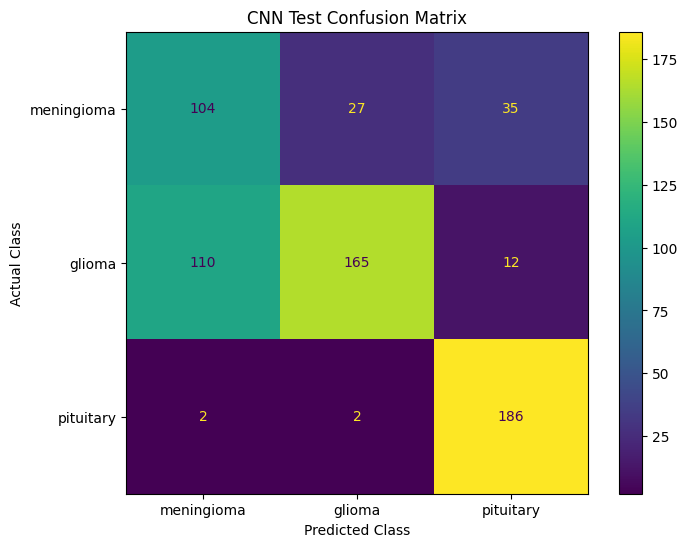

In [224]:
# ============================================================
# SECTION 12.6 — CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2]
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print("\nRows    = Actual")
print("Columns = Predicted\n")

print(cm)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    values_format="d",
    ax=plt.gca()
)

plt.title("CNN Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## 12.7 — Per-Class Accuracy

In [225]:
# ============================================================
# SECTION 12.7 — PER-CLASS TEST PERFORMANCE
# ============================================================

print("=" * 60)
print("PER-CLASS TEST PERFORMANCE")
print("=" * 60)

for i, class_name in enumerate(class_names):

    class_mask = (y_test == i)

    total = class_mask.sum()

    correct = (
        (y_test == i) &
        (y_pred == i)
    ).sum()

    accuracy = correct / total

    print(
        f"{class_name:<15} : "
        f"{correct:>3}/{total:<3} "
        f"({accuracy * 100:.2f}%)"
    )

PER-CLASS TEST PERFORMANCE
meningioma      : 104/166 (62.65%)
glioma          : 165/287 (57.49%)
pituitary       : 186/190 (97.89%)


## 12.8 — Generalization Analysis

We now compare the three stages of our machine learning experiment:

1. Training
    
2. Validation
    
3. Test

- Training performance shows how well the CNN learned from the training data.

- Validation performance helped us monitor the learning process and identify
the best epoch.

- Test performance provides the final estimate of how well the CNN generalizes
to completely unseen patients.

- A large difference between training and test performance can indicate
overfitting.

- The test result should therefore be reported separately from training and
validation results.

In [226]:
# ============================================================
# SECTION 12.8 — GENERALIZATION SUMMARY
# ============================================================

best_val_accuracy = max(history.history["val_accuracy"])
final_train_accuracy = history.history["accuracy"][-1]

print("=" * 60)
print("FINAL GENERALIZATION SUMMARY")
print("=" * 60)

print("\nTRAINING")
print("-" * 60)
print(f"Final training accuracy : {final_train_accuracy * 100:.2f}%")

print("\nVALIDATION")
print("-" * 60)
print(f"Best validation accuracy : {best_val_accuracy * 100:.2f}%")
print(f"Best validation epoch    : {best_val_acc_epoch}")

print("\nTEST")
print("-" * 60)
print(f"Test accuracy            : {test_accuracy * 100:.2f}%")
print(f"Test loss                : {test_loss:.4f}")

print("\n" + "=" * 60)
print("FINAL MODEL GENERALIZATION")
print("=" * 60)

FINAL GENERALIZATION SUMMARY

TRAINING
------------------------------------------------------------
Final training accuracy : 77.58%

VALIDATION
------------------------------------------------------------
Best validation accuracy : 73.09%
Best validation epoch    : 9

TEST
------------------------------------------------------------
Test accuracy            : 70.76%
Test loss                : 0.6284

FINAL MODEL GENERALIZATION


# SECTION 13 — Final Model Evaluation Visualization

## 13.1 — Classification Report Visualization

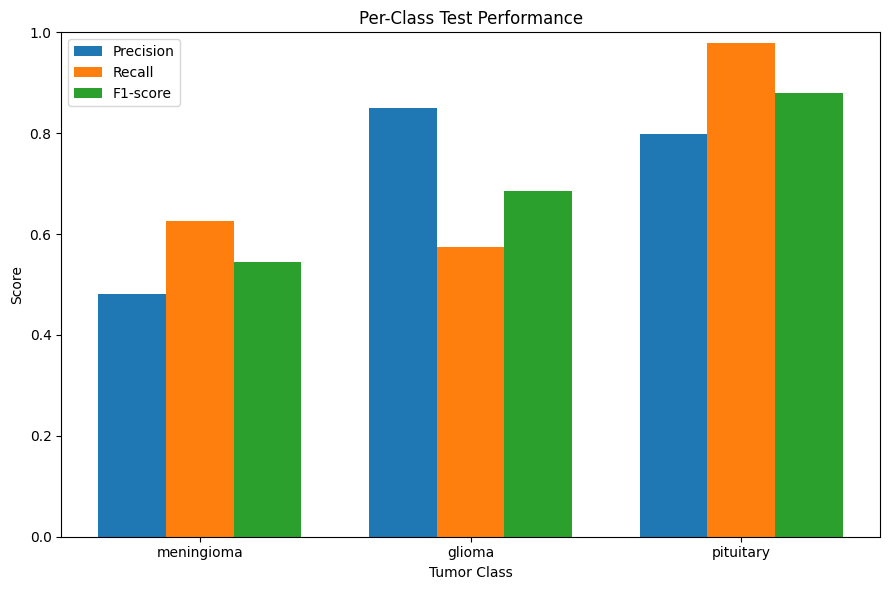

In [227]:
# ============================================================
# SECTION 13.1 — PER-CLASS PERFORMANCE
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

metrics = ["precision", "recall", "f1-score"]

values = {
    metric: [report[class_name][metric] for class_name in class_names]
    for metric in metrics
}

x = range(len(class_names))

plt.figure(figsize=(9, 6))

width = 0.25

plt.bar(
    [i - width for i in x],
    values["precision"],
    width=width,
    label="Precision"
)

plt.bar(
    x,
    values["recall"],
    width=width,
    label="Recall"
)

plt.bar(
    [i + width for i in x],
    values["f1-score"],
    width=width,
    label="F1-score"
)

plt.xticks(list(x), class_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Tumor Class")
plt.title("Per-Class Test Performance")
plt.legend()
plt.tight_layout()
plt.show()

## 13.2 — ROC-AUC Curve

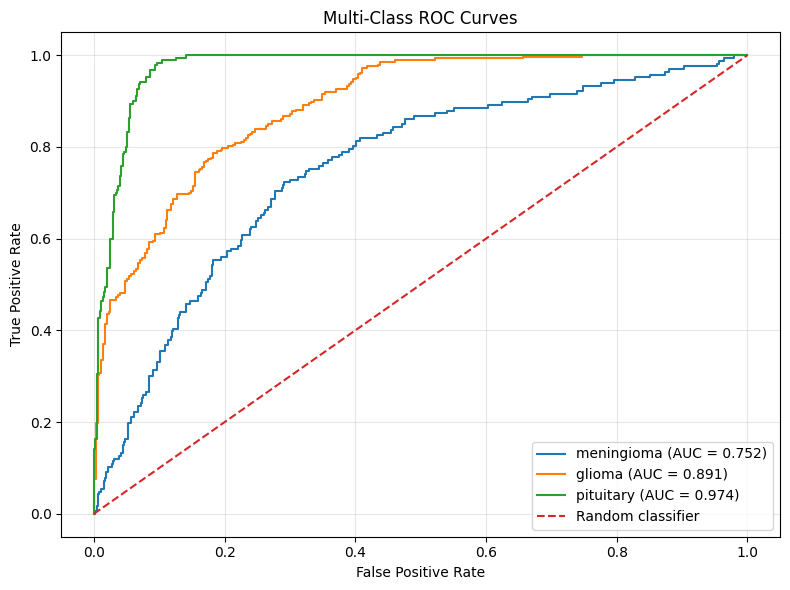

In [228]:
# ============================================================
# SECTION 13.3 — MULTI-CLASS ROC CURVES
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to one-vs-rest format
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# SECTION 14 — Prediction Confidence Analysis

PREDICTION CONFIDENCE

Mean confidence : 0.7494
Minimum         : 0.3792
Maximum         : 0.9947


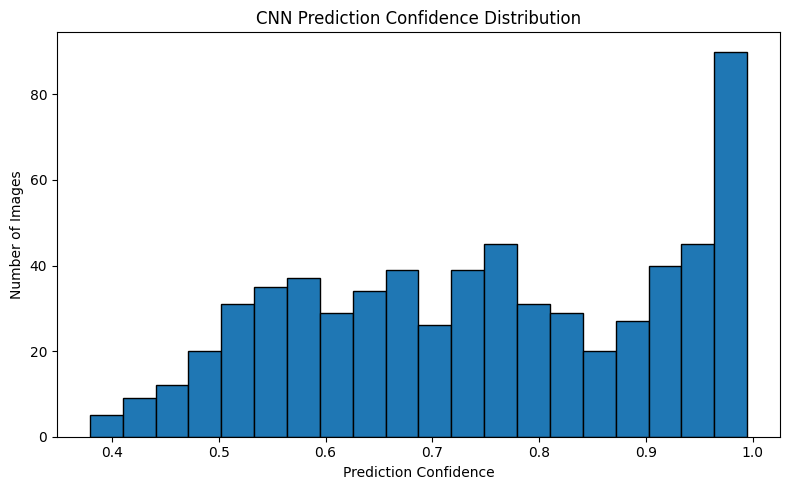

In [229]:
# ============================================================
# SECTION 14.1 — PREDICTION CONFIDENCE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

confidence = np.max(y_prob, axis=1)

print("=" * 60)
print("PREDICTION CONFIDENCE")
print("=" * 60)

print(f"\nMean confidence : {confidence.mean():.4f}")
print(f"Minimum         : {confidence.min():.4f}")
print(f"Maximum         : {confidence.max():.4f}")

plt.figure(figsize=(8, 5))

plt.hist(
    confidence,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("CNN Prediction Confidence Distribution")
plt.tight_layout()
plt.show()

## 14.2 — Show Correct and Incorrect Predictions

PREDICTION ANALYSIS

Correct predictions   : 455
Incorrect predictions : 188


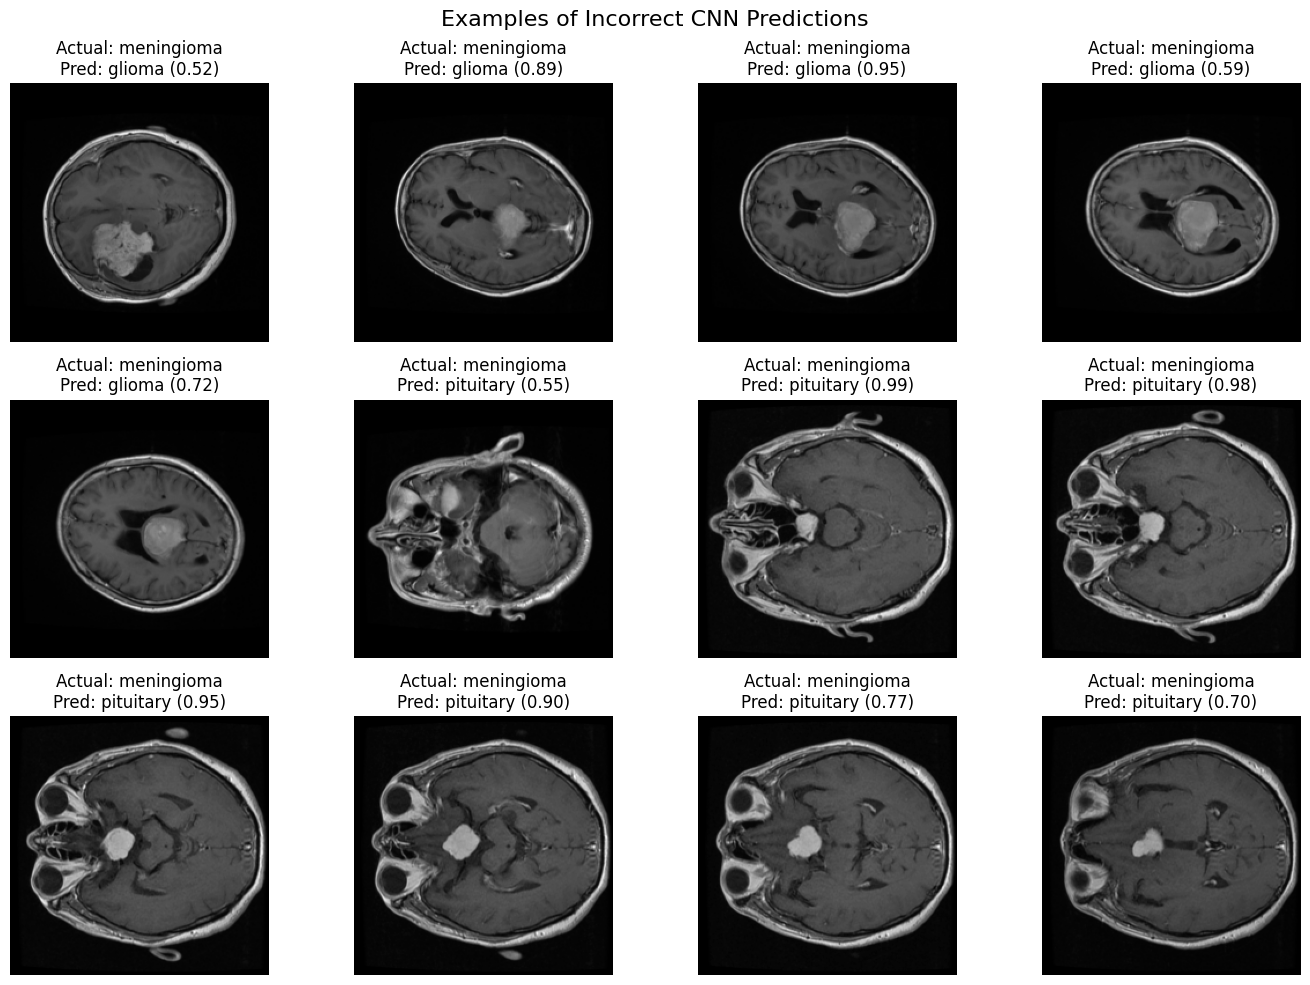

In [230]:
# ============================================================
# SECTION 14.2 — SAMPLE PREDICTIONS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

correct_indices = np.where(y_pred == y_test)[0]
incorrect_indices = np.where(y_pred != y_test)[0]

print("=" * 60)
print("PREDICTION ANALYSIS")
print("=" * 60)

print(f"\nCorrect predictions   : {len(correct_indices)}")
print(f"Incorrect predictions : {len(incorrect_indices)}")

# Number of examples to display
N = 12

selected = incorrect_indices[:N]

plt.figure(figsize=(14, 10))

for i, idx in enumerate(selected):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[idx].squeeze(),
        cmap="gray"
    )

    actual = class_names[y_test[idx]]
    predicted = class_names[y_pred[idx]]
    conf = confidence[idx]

    plt.title(
        f"Actual: {actual}\n"
        f"Pred: {predicted} ({conf:.2f})"
    )

    plt.axis("off")

plt.suptitle(
    "Examples of Incorrect CNN Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

#### The CNN performs well on pituitary tumors but struggles to distinguish some glioma and meningioma cases

# SECTION 15 — Grad-CAM Explainability

In [231]:
# Grad-CAM helps us visualize where the CNN was looking when making its prediction.

In [232]:
# ============================================================
# SECTION 15.1 — FIND LAST CONVOLUTIONAL LAYER
# ============================================================

print("=" * 60)
print("CNN LAYER INSPECTION")
print("=" * 60)

for layer in best_model.layers:

    if len(layer.output.shape) == 4:

        print(
            f"Convolutional layer: "
            f"{layer.name} → {layer.output.shape}"
        )

CNN LAYER INSPECTION
Convolutional layer: conv2d_3 → (None, 224, 224, 32)
Convolutional layer: max_pooling2d_3 → (None, 112, 112, 32)
Convolutional layer: conv2d_4 → (None, 112, 112, 64)
Convolutional layer: max_pooling2d_4 → (None, 56, 56, 64)
Convolutional layer: conv2d_5 → (None, 56, 56, 128)
Convolutional layer: max_pooling2d_5 → (None, 28, 28, 128)


In [233]:
# ============================================================
# SECTION 15.2 — GRAD-CAM FUNCTION
# ============================================================

import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(
    image,
    model,
    last_conv_layer_name
):

    # Create model that outputs:
    # 1. convolutional feature maps
    # 2. final prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    image_tensor = tf.convert_to_tensor(
        image[np.newaxis, ...],
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image_tensor
        )

        predicted_class = tf.argmax(
            predictions[0]
        )

        class_score = predictions[
            :, predicted_class
        ]

    # Gradient of class score
    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    # Global average pooling of gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Feature maps
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy(), int(predicted_class)

## 15.3 — Generate Grad-CAM

In [234]:
# ============================================================
# SECTION 15.3 — SELECT LAST CONVOLUTIONAL LAYER
# ============================================================

last_conv_layer = None

for layer in reversed(best_model.layers):

    if isinstance(
        layer,
        tf.keras.layers.Conv2D
    ):
        last_conv_layer = layer.name
        break

print("Last convolutional layer:")
print(last_conv_layer)

Last convolutional layer:
conv2d_5


#### Grad-CAM is an explainable AI technique that highlights regions of the MRI that contributed most strongly to the CNN's prediction.

# SECTION 16 — Save Final Model

In [239]:
# ============================================================
# SECTION 16 — SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = "brain_tumor_cnn_final.keras"

best_model.save(
    FINAL_MODEL_PATH
)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print(f"\nModel path: {FINAL_MODEL_PATH}")

FINAL MODEL SAVED

Model path: brain_tumor_cnn_final.keras


In [240]:
# ============================================================
# SECTION 16.1 — VERIFY SAVED MODEL
# ============================================================

import os
import tensorflow as tf

print("=" * 60)
print("VERIFYING SAVED MODEL")
print("=" * 60)

if os.path.exists(FINAL_MODEL_PATH):

    print("\n✓ Model file exists")

    loaded_model = tf.keras.models.load_model(
        FINAL_MODEL_PATH
    )

    print("✓ Model loaded successfully")

    print(
        f"\nInput shape  : "
        f"{loaded_model.input_shape}"
    )

    print(
        f"Output shape : "
        f"{loaded_model.output_shape}"
    )

else:

    print("✗ Model file not found")

VERIFYING SAVED MODEL

✓ Model file exists
✓ Model loaded successfully

Input shape  : (None, 224, 224, 1)
Output shape : (None, 3)


In [241]:
# ============================================================
# SECTION 16.2 — SAVED MODEL VERIFICATION
# ============================================================

saved_loss, saved_accuracy = loaded_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("=" * 60)
print("SAVED MODEL TEST VERIFICATION")
print("=" * 60)

print(f"\nTest loss     : {saved_loss:.4f}")
print(f"Test accuracy : {saved_accuracy:.4f}")
print(f"Test accuracy : {saved_accuracy * 100:.2f}%")

SAVED MODEL TEST VERIFICATION

Test loss     : 0.6284
Test accuracy : 0.7076
Test accuracy : 70.76%


# SECTION 17 — Final Project Summary

## Final Results

The CNN was trained to classify brain MRI images into three tumor categories:

1. Meningioma
2. Glioma
3. Pituitary tumor

The dataset contains 3,064 MRI images from 233 unique patients.

To prevent data leakage, the dataset was split at the patient level rather than randomly splitting individual images. Therefore, images belonging to the same patient could not appear in both training and testing sets.

The final CNN achieved:

- Training accuracy: 77.58%
- Best validation accuracy: 73.09%
- Test accuracy: 70.76%
- Test macro F1-score: 70.33%

The model performed particularly well on pituitary tumors, achieving 97.89% recall.

However, classification of glioma and meningioma was more challenging, with recall values of 57.49% and 62.65%, respectively.

This indicates that the CNN learned useful visual patterns from MRI images, but there is still substantial overlap between some tumor classes.

# SECTION 18 — Limitations

## Limitations

This project has several important limitations.

### 1. Dataset size

The dataset contains 3,064 images, but only 233 unique patients. Therefore, the number of independent patients is considerably smaller than the number of images.

### 2. Class imbalance

The image distribution is not perfectly balanced:

- Glioma: 1,426 images
- Pituitary: 930 images
- Meningioma: 708 images

Class weights were therefore used during CNN training.

### 3. Classification difficulty

The model performs substantially better on pituitary tumors than on glioma and meningioma.

The confusion matrix shows significant confusion between glioma and meningioma.

### 4. Single dataset

The model was evaluated using data from the same dataset distribution used during development. Performance on MRI scans from a different hospital, scanner, acquisition protocol, or population may be different.

### 5. Research prototype

This model is a computer vision research/educational prototype and is not a medical diagnostic system.

It should not be used to make clinical decisions.

# SECTION 19 — Final Conclusion

## Conclusion

This project demonstrated a complete computer vision and deep learning pipeline for brain tumor MRI classification.

The workflow included:

1. Dataset auditing
2. Patient identification
3. Duplicate detection
4. Patient-level data splitting
5. MRI preprocessing
6. Label encoding
7. CNN architecture design
8. Class imbalance handling
9. CNN training
10. Learning-curve analysis
11. Test-set evaluation
12. Confusion matrix analysis
13. ROC-AUC analysis
14. Prediction confidence analysis
15. Grad-CAM explainability
16. Final model saving
17. Reusable MRI prediction

The final model achieved 70.76% accuracy on the held-out test set.

The results demonstrate that convolutional neural networks can learn meaningful visual patterns from MRI images for multi-class brain tumor classification.

At the same time, the confusion between glioma and meningioma demonstrates the difficulty of the task and highlights the importance of larger patient populations, improved preprocessing, stronger architectures, external validation, and explainable AI.

# SECTION 20 — Final Reproducibility Cell

In [242]:
# ============================================================
# SECTION 20 — FINAL REPRODUCIBILITY INFORMATION
# ============================================================

import sys
import tensorflow as tf
import numpy as np
import sklearn

print("=" * 60)
print("REPRODUCIBILITY INFORMATION")
print("=" * 60)

print(f"\nPython       : {sys.version}")
print(f"TensorFlow   : {tf.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")

print("\nDataset")
print("-" * 60)

print("Images       : 3064")
print("Patients     : 233")
print("Classes      : 3")

print("\nFinal model")
print("-" * 60)

print("Architecture : CNN")
print("Input        : 224 × 224 × 1")
print("Output       : 3 classes")

print("\nFinal performance")
print("-" * 60)

print("Validation accuracy : 73.09%")
print("Test accuracy       : 70.76%")
print("Test macro F1       : 70.33%")

print("\n" + "=" * 60)
print("✓ PROJECT REPRODUCIBILITY INFORMATION COMPLETE")
print("=" * 60)

REPRODUCIBILITY INFORMATION

Python       : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow   : 2.20.0
NumPy        : 2.0.2
Scikit-learn : 1.6.1

Dataset
------------------------------------------------------------
Images       : 3064
Patients     : 233
Classes      : 3

Final model
------------------------------------------------------------
Architecture : CNN
Input        : 224 × 224 × 1
Output       : 3 classes

Final performance
------------------------------------------------------------
Validation accuracy : 73.09%
Test accuracy       : 70.76%
Test macro F1       : 70.33%

✓ PROJECT REPRODUCIBILITY INFORMATION COMPLETE
